# Lib Installation

In [1]:
!pip install  lightning pytorch-lightning torchvision  tqdm python-dotenv PyYAML wilds

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 853.6/853.6 kB 18.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 35.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.2/126.2 kB 17.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.8/78.8 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 44.0 MB/s eta 0:00:00


In [2]:
# Cell 1: Install required libs (run in a cell)
!pip install lightning pytorch-lightning torchvision tqdm python-dotenv PyYAML wilds torchmetrics

# Config

In [1]:
config = {
    "algo": "FOND",
    "dataset": ["OfficeHome"],  # Only OfficeHome
    "test_set_id": 0,  # 0, 1, 2, or 3
    # Paths
    "data_dir": {"OfficeHome": "/kaggle/input/officehome/OfficeHome/"},
    "log_dir": "./logs",
    # Training settings
    "n_epochs": 5001,  # Converted from 5001 steps (~15 epochs at 32 batch size)
    "checkpoint_freq": 4999,  # Evaluate every epoch (was 300 steps)
    "holdout_fraction": 0.2,
    # Model checkpointing
    "model_checkpoint": {
        "metric": "val/oacc",
        "maximize": True
    },
    # Seeds
    "overall_seed": 1,
    "trial_id": 0,
    "hparam_id": 0,  # 0=default hparams, 1-4=random variants
    # System
    "num_workers": 4,
    # Dataset config (from sweep)
    "overlap": "high",  # Can keep as-is
    "num_classes": None,
    "num_domain_linked_classes": None,
    # AutoFOND specific (disabled for baseline)
    "auto_augment": False,
    "augment_search_epochs": 5,
    "augment_policy_size": 5,
    "augment_num_policies": 3,
    # Teacher paths (empty for regular FOND)
    "teacher_paths": {}
}


In [2]:
config.update({
    "backbone": "convnext_tiny",
    "pretrained": True,
    "freeze_backbone": True,   # IMPORTANT
    "feature_dim": 768,        # ConvNeXt-Tiny output feature dim
})


# Imports

In [3]:
import math
from typing import List, Any, Dict, Optional, Callable, Tuple
import argparse
import logging
import hashlib
import numpy as np
from collections import Counter
import collections
import time
from datetime import datetime
import lightning as L
from tqdm import tqdm
import csv
import json
from pathlib import Path
import os
import torch
import torchmetrics
import torchvision.datasets.folder
from PIL import Image, ImageFile
from torch.utils.data import ConcatDataset, Dataset, Subset, TensorDataset
from torchvision import transforms
from torchvision.datasets import MNIST, ImageFolder
from torchvision.transforms.functional import rotate
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models

# Removed: import clip
# Optional: remove Camelyon17Dataset if not using Wilds
# from wilds.datasets.camelyon17_dataset import Camelyon17Dataset


# SRC

## Domain Creation

In [4]:



def create_domains(
    num_classes: int, num_linked: int, num_train_domains: int
) -> List[List[int]]:
    """
    Determine and distribute domain-linked and domain-shared classes.
    Domain-linked classes will come from the same domain, i.e., idx=0.
    Domain-shared classes will exist in each of the remaining domains

    Args:
        num_classes: number of overall classes within all the domains
        num_linked: number of classes that are linked to an individual domain
        num_train_domains: number of different training domains
    """
    assert num_linked <= num_classes
    domain_shared = [i for i in range(num_linked, num_classes)]
    domain_linked = [i for i in range(num_linked)]
    logging.info(f"Domain-shared classes: {domain_shared}")
    logging.info(f"Domain-linked classes: {domain_linked}")
    # domains = [domain_shared.copy() for i in range(num_train_domains)]
    domains = [[] for i in range(num_train_domains)]

    # first domain is domain-linked only
    domains[0] = domain_linked
    # other domains contain domain-shared only
    domains[1:] = [domain_shared.copy() for i in range(1, num_train_domains)]

    logging.info(f"domains[0]: {domains[0]}")
    logging.info(f"domains[1:]: {domains[1:]}")

    return domains


def create_domains_1(
    num_classes: int, num_linked: int, num_domains: int
) -> List[List[int]]:
    """
    Args:
        num_classes: number of overall classes within all the domains
        num_linked: number of classes that are linked to an individual domain
        num_domains: number of different domains, including test domain
    """
    assert num_linked < num_classes
    domain_shared = [i for i in range(num_linked, num_classes)]
    print(f"Shared classes: {domain_shared}")
    num_train_domains = num_domains - 1
    domains = [domain_shared.copy() for i in range(num_train_domains)]

    for class_idx in range(num_linked):
        domain_idx = class_idx % num_train_domains
        domains[domain_idx].append(class_idx)
    return domains


def create_domains_2(
    num_classes: int, num_linked_ratio: float, num_domains: int
) -> List[List[int]]:
    """
    Args:
        num_classes: number of overall classes within all the domains
        num_linked_ratio: ratio of linked classes to the total number of classes
        num_domains: number of different domains, including test domain
    """
    num_linked = math.floor(num_linked_ratio * num_classes)
    return create_domains_1(num_classes, num_linked, num_domains)



# Testing
create_domains(num_classes=10, num_linked=5, num_train_domains=3)
# Testing domain linked only
create_domains(num_classes=10, num_linked=10, num_train_domains=3)

# Testing same classes with different overlap
domains = create_domains_1(num_classes=10, num_linked=3, num_domains=4)
print(domains)
domains = create_domains_1(num_classes=10, num_linked=5, num_domains=4)
print(domains)

# Testing different classes with same overlap percentage
domains = create_domains_2(num_classes=10, num_linked_ratio=0.2, num_domains=4)
print(domains)
domains = create_domains_2(num_classes=5, num_linked_ratio=0.2, num_domains=4)
print(domains)


Shared classes: [3, 4, 5, 6, 7, 8, 9]
[[3, 4, 5, 6, 7, 8, 9, 0], [3, 4, 5, 6, 7, 8, 9, 1], [3, 4, 5, 6, 7, 8, 9, 2]]
Shared classes: [5, 6, 7, 8, 9]
[[5, 6, 7, 8, 9, 0, 3], [5, 6, 7, 8, 9, 1, 4], [5, 6, 7, 8, 9, 2]]
Shared classes: [2, 3, 4, 5, 6, 7, 8, 9]
[[2, 3, 4, 5, 6, 7, 8, 9, 0], [2, 3, 4, 5, 6, 7, 8, 9, 1], [2, 3, 4, 5, 6, 7, 8, 9]]
Shared classes: [1, 2, 3, 4]
[[1, 2, 3, 4, 0], [1, 2, 3, 4], [1, 2, 3, 4]]


## Hparams

In [5]:
"""
Hyper-parameter registry
"""


def seed_hash(*args):
    """
    Derive an integer hash from all args, for use as a random seed.
    """
    args_str = str(args)
    return int(hashlib.md5(args_str.encode("utf-8")).hexdigest(), 16) % (2**31)


def _define_hparam(hparams, hparam_name, default_val, random_val_fn):
    hparams[hparam_name] = (hparams, hparam_name, default_val, random_val_fn)


def _hparams(algorithm, dataset, random_seed):
    """
    Global registry of hyperparams. Each entry is a (default, random) tuple.
    New algorithms / networks / etc. should add entries here.
    """
    SMALL_IMAGES = ["Debug28", "RotatedMNIST", "ColoredMNIST"]

    hparams = {}

    def _hparam(name, default_val, random_val_fn):
        """Define a hyperparameter. random_val_fn takes a RandomState and
        returns a random hyperparameter value."""
        assert name not in hparams
        random_state = np.random.RandomState(seed_hash(random_seed, name))
        hparams[name] = (default_val, random_val_fn(random_state))

    # Unconditional hparam definitions.

    _hparam("data_augmentation", True, lambda r: True)
    _hparam("resnet18", True, lambda r: True)
    _hparam("resnet_dropout", 0.0, lambda r: r.choice([0.0, 0.1, 0.5]))
    _hparam("class_balanced", False, lambda r: False)
    _hparam("nonlinear_classifier", False, lambda r: False)

    # Algorithm-specific hparam definitions. Each block of code below
    # corresponds to exactly one algorithm.

    if (
        algorithm == "FOND"
        or algorithm == "FOND_NC"
        or algorithm == "FOND_N"
        or algorithm == "NOC"
    ):
        _hparam("temperature", 0.07, lambda r: 0.07 * r.uniform(0.75, 1.25))
        _hparam("base_temperature", 0.07, lambda r: 0.07)
        _hparam("xdom_lmbd", 1, lambda r: 10 ** r.uniform(-1, 3))
        _hparam("error_lmbd", 1, lambda r: 10 ** r.uniform(-1, 3))
        _hparam("xda_alpha", 1, lambda r: 10 ** r.uniform(0, 1))
        _hparam("xda_beta", 1, lambda r: 10 ** r.uniform(0, 1))
    elif (
        algorithm == "FOND_Distillation_Separate_Projector"
        or algorithm == "FOND_Distillation_Teacher_Projector"
        or algorithm == "FOND_Distillation_Student_Projector"
    ):
        _hparam("temperature", 0.07, lambda r: 0.07 * r.uniform(0.75, 1.25))
        _hparam("base_temperature", 0.07, lambda r: 0.07)
        _hparam("xdom_lmbd", 1, lambda r: 10 ** r.uniform(-1, 3))
        _hparam("error_lmbd", 1, lambda r: 10 ** r.uniform(-1, 3))
        _hparam("xda_alpha", 1, lambda r: 10 ** r.uniform(0, 1))
        _hparam("xda_beta", 1, lambda r: 10 ** r.uniform(0, 1))
        _hparam("distillation_temperature", 1, lambda r: r.uniform(1, 20))

    # Dataset-and-algorithm-specific hparam definitions. Each block of code
    # below corresponds to exactly one hparam. Avoid nested conditionals.

    if dataset in SMALL_IMAGES:
        _hparam("lr", 1e-3, lambda r: 10 ** r.uniform(-4.5, -2.5))
    else:
        _hparam("lr", 5e-5, lambda r: 10 ** r.uniform(-5, -3.5))

    if dataset in SMALL_IMAGES:
        _hparam("weight_decay", 0.0, lambda r: 0.0)
    else:
        _hparam("weight_decay", 0.0, lambda r: 10 ** r.uniform(-6, -2))

    if dataset in SMALL_IMAGES:
        _hparam("batch_size", 64, lambda r: int(2 ** r.uniform(3, 9)))
    elif algorithm == "ARM":
        _hparam("batch_size", 8, lambda r: 8)
    elif dataset == "DomainNet":
        _hparam("batch_size", 32, lambda r: int(2 ** r.uniform(3, 5)))
    else:
        _hparam("batch_size", 32, lambda r: int(2 ** r.uniform(3, 5.5)))

    return hparams


def default_hparams(algorithm, dataset):
    return {a: b for a, (b, c) in _hparams(algorithm, dataset, 0).items()}


def random_hparams(algorithm, dataset, seed):
    return {a: c for a, (b, c) in _hparams(algorithm, dataset, seed).items()}
    hparams.update({
    "backbone": "convnext_tiny",
    "device": "cuda"
})



## Misc

In [6]:

class _SplitDataset(torch.utils.data.Dataset):
    """Used by split_dataset"""

    def __init__(self, underlying_dataset, keys):
        super(_SplitDataset, self).__init__()
        self.underlying_dataset = underlying_dataset
        self.keys = keys

    def __getitem__(self, key):
        return self.underlying_dataset[self.keys[key]]

    def __len__(self):
        return len(self.keys)


def split_dataset(dataset, n, seed=0):
    """
    Return a pair of datasets corresponding to a random split of the given
    dataset, with n datapoints in the first dataset and the rest in the last,
    using the given random seed
    """
    assert n <= len(dataset)
    keys = list(range(len(dataset)))
    np.random.RandomState(seed).shuffle(keys)
    keys_1 = keys[:n]
    keys_2 = keys[n:]
    return _SplitDataset(dataset, keys_1), _SplitDataset(dataset, keys_2)


def seed_hash(*args):
    """
    Derive an integer hash from all args, for use as a random seed.
    """
    args_str = str(args)
    return int(hashlib.md5(args_str.encode("utf-8")).hexdigest(), 16) % (2**31)


def make_weights_for_balanced_classes(dataset):
    counts = Counter()
    classes = []
    for _, y in dataset:
        y = int(y)
        counts[y] += 1
        classes.append(y)

    n_classes = len(counts)

    weight_per_class = {}
    for y in counts:
        weight_per_class[y] = 1 / (counts[y] * n_classes)

    weights = torch.zeros(len(dataset))
    for i, y in enumerate(classes):
        weights[i] = weight_per_class[int(y)]

    return weights
def compute_loss(network, loader, device):
    """
    Compute average loss for a given loader.
    Returns: average loss value
    """
    total_loss = 0.0
    num_batches = 0

    network.eval()
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            y = y.to(device)
            p = network.predict(x)

            # Compute loss
            loss = torch.nn.functional.cross_entropy(p, y, reduction='mean')
            total_loss += loss.item()
            num_batches += 1

    network.train()

    avg_loss = total_loss / num_batches if num_batches > 0 else 0.0
    return avg_loss

def accuracy(network, loader, weights, device, dataset):
    correct = 0
    total = 0
    weights_offset = 0
    overlapping_classes = dataset.overlapping_classes
    num_classes = dataset.num_classes

    f1_score = torchmetrics.F1Score(
        task="multiclass", num_classes=num_classes, average="macro"
    ).to(device)
    per_class_accuracy = torchmetrics.Accuracy(
        task="multiclass",
        num_classes=num_classes,
        average=None,
    ).to(device)
    accuracy = torchmetrics.Accuracy(
        task="multiclass",
        num_classes=num_classes,
        average="macro",
    ).to(device)
    recall = torchmetrics.Recall(
        task="multiclass",
        num_classes=num_classes,
        average="macro",
    ).to(device)
    precision = torchmetrics.Precision(
        task='multiclass',  # ✅ Fixed typo
        num_classes=num_classes,
        average='macro'
    ).to(device)
    conf_mat = torchmetrics.ConfusionMatrix(
        task="multiclass",
        num_classes=num_classes
    ).to(device)  # ✅ Added .to(device)

    network.eval()
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            y = y.to(device)
            p = network.predict(x)

            if weights is None:
                batch_weights = torch.ones(len(x))
            else:
                batch_weights = weights[weights_offset : weights_offset + len(x)]
                weights_offset += len(x)
            batch_weights = batch_weights.to(device)

            if p.size(1) == 1:
                correct += (
                    (p.gt(0).eq(y).float() * batch_weights.view(-1, 1)).sum().item()
                )
            else:
                correct += (p.argmax(1).eq(y).float() * batch_weights).sum().item()
            total += batch_weights.sum().item()

            # update metrics
            accuracy.update(p, y)
            recall.update(p, y)
            precision.update(p, y)
            f1_score.update(p, y)
            per_class_accuracy.update(p, y)
            conf_mat.update(p, y)

    network.train()
    compute_acc = accuracy.compute().item()
    compute_recall = recall.compute().item()
    compute_precision = precision.compute().item()  # ✅ Fixed typo
    compute_f1 = f1_score.compute().item()
    compute_per_class_acc = per_class_accuracy.compute().cpu().numpy()
    cm_compute = conf_mat.compute().cpu().numpy()  # ✅ Convert to numpy

    overlap_class_acc = []
    non_overlap_class_acc = []
    per_class_acc_dict = {}
    for i in range(num_classes):
        per_class_acc_dict[i] = float(compute_per_class_acc[i])
        if i in overlapping_classes:
            overlap_class_acc.append(compute_per_class_acc[i])
        else:
            non_overlap_class_acc.append(compute_per_class_acc[i])

    if len(non_overlap_class_acc) == 0:
        non_overlap_class_acc = -1
    else:
        non_overlap_class_acc = np.mean(non_overlap_class_acc)
    if len(overlap_class_acc) == 0:
        overlap_class_acc = -1
    else:
        overlap_class_acc = np.mean(overlap_class_acc)

    other_acc = correct / total

    return (
        float(compute_acc),
        float(compute_recall),
        float(compute_f1),
        float(compute_precision),      # ✅ Moved before oacc/nacc
        float(overlap_class_acc),
        float(non_overlap_class_acc),
        per_class_acc_dict,
        cm_compute
    )
class _InfiniteSampler(torch.utils.data.Sampler):
    """Wraps another Sampler to yield an infinite stream."""

    def __init__(self, sampler):
        self.sampler = sampler

    def __iter__(self):
        while True:
            for batch in self.sampler:
                yield batch


class InfiniteDataLoader:
    def __init__(self, dataset, weights, batch_size, num_workers):
        super().__init__()

        if weights is not None:
            sampler = torch.utils.data.WeightedRandomSampler(
                weights, replacement=True, num_samples=batch_size
            )
        else:
            sampler = torch.utils.data.RandomSampler(dataset, replacement=True)

        if weights == None:
            weights = torch.ones(len(dataset))

        batch_sampler = torch.utils.data.BatchSampler(
            sampler, batch_size=batch_size, drop_last=True
        )

        self._infinite_iterator = iter(
            torch.utils.data.DataLoader(
                dataset,
                num_workers=num_workers,
                batch_sampler=_InfiniteSampler(batch_sampler),
            )
        )

    def __iter__(self):
        while True:
            yield next(self._infinite_iterator)

    def __len__(self):
        raise ValueError


class FastDataLoader:
    """DataLoader wrapper with slightly improved speed by not respawning worker
    processes at every epoch."""

    def __init__(self, dataset, batch_size, num_workers):
        super().__init__()

        batch_sampler = torch.utils.data.BatchSampler(
            torch.utils.data.RandomSampler(dataset, replacement=False),
            batch_size=batch_size,
            drop_last=False,
        )

        self._infinite_iterator = iter(
            torch.utils.data.DataLoader(
                dataset,
                num_workers=num_workers,
                batch_sampler=_InfiniteSampler(batch_sampler),
            )
        )

        self._length = len(batch_sampler)

    def __iter__(self):
        for _ in range(len(self)):
            yield next(self._infinite_iterator)

    def __len__(self):
        return self._length


def config_logging():
    """
    Reusable code for formatting the logger
    """
    logging.basicConfig(
        format="%(asctime)s,%(msecs)03d %(levelname)-8s [%(filename)s:%(funcName)s:%(lineno)d] %(message)s",
        datefmt="%Y-%m-%d:%H:%M:%S",
        level=logging.INFO,
    )


## Simple Logger

In [7]:
"""
Simple CSV logger to replace W&B during development
Keeps the same interface for easy swap later
"""
class CSVLogger:
    """Lightweight logger that writes metrics to CSV"""

    def __init__(self, csv_path: str, root_dir:str=None):
        self.csv_path = Path(csv_path)
        self.csv_path.parent.mkdir(parents=True, exist_ok=True)
        self.fieldnames = None
        self.file = None
        self.writer = None
        self._init_csv()
        self.root = root_dir if root_dir is not None else csv_path.parent
    def _init_csv(self):
        """Initialize CSV file with headers"""
        self.file = open(self.csv_path, 'w', newline='')
        self.writer = None  # Will be created on first log
    def return_root(self):
        return self.root
    def log(self, metrics: Dict[str, Any], step: Optional[int] = None):
        """
        Log metrics to CSV

        Args:
            metrics: Dictionary of metric_name -> value
            step: Training step (optional, will be added if provided)
        """
        if step is not None:
            metrics = {"step": step, **metrics}

        # Flatten nested dictionaries (e.g., {"train/acc": 0.9})
        flat_metrics = {}
        for key, value in metrics.items():
            if isinstance(value, dict):
                for subkey, subvalue in value.items():
                    flat_metrics[f"{key}/{subkey}"] = subvalue
            else:
                flat_metrics[key] = value

        # Initialize writer with fieldnames on first call
        if self.writer is None:
            self.fieldnames = list(flat_metrics.keys())
            self.writer = csv.DictWriter(self.file, fieldnames=self.fieldnames)
            self.writer.writeheader()

        # Add new fields if they appear
        new_fields = set(flat_metrics.keys()) - set(self.fieldnames)
        if new_fields:
            self.fieldnames.extend(sorted(new_fields))
            # Rewrite file with new headers
            self.file.close()
            self._rewrite_with_new_fields(flat_metrics)
            return

        self.writer.writerow(flat_metrics)
        self.file.flush()  # Ensure immediate write

    def _rewrite_with_new_fields(self, new_row: Dict[str, Any]):
        """Rewrite CSV when new fields are discovered"""
        # Read existing rows
        with open(self.csv_path, 'r') as f:
            reader = csv.DictReader(f)
            existing_rows = list(reader)

        # Rewrite with updated fieldnames
        self.file = open(self.csv_path, 'w', newline='')
        self.writer = csv.DictWriter(self.file, fieldnames=self.fieldnames)
        self.writer.writeheader()
        for row in existing_rows:
            self.writer.writerow(row)
        self.writer.writerow(new_row)
        self.file.flush()

    def save_config(self, config: Dict[str, Any], path: Optional[str] = None):
        """Save experiment config as JSON"""
        if path is None:
            path = self.csv_path.parent / "config.json"
        with open(path, 'w') as f:
            json.dump(config, f, indent=2)

    def close(self):
        """Close CSV file"""
        if self.file:
            self.file.close()

    def __enter__(self):
        return self

    def __exit__(self, exc_type, exc_val, exc_tb):
        self.close()


class PrintLogger:
    """Even simpler logger that just prints to console"""

    def log(self, metrics: Dict[str, Any], step: Optional[int] = None):
        step_str = f"[Step {step}] " if step is not None else ""
        metric_str = ", ".join(f"{k}={v:.4f}" if isinstance(v, float) else f"{k}={v}"
                               for k, v in metrics.items())
        print(f"{step_str}{metric_str}")

    def save_config(self, config: Dict[str, Any], path: Optional[str] = None):
        print(f"Config: {json.dumps(config, indent=2)}")

    def close(self):
        pass


# DADA

In [8]:
import os, json, random, logging
import numpy as np
import torch
import torch.nn as nn

from torchvision import transforms
from torch.utils.data import DataLoader

torch.manual_seed(0)
np.random.seed(0)
random.seed(0)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)


Device: cuda


In [9]:
class DiffGaussianNoise(nn.Module):
    def __init__(self, std=0.05):
        super().__init__()
        self.std = std

    def forward(self, x):
        if not self.training:
            return x
        noise = torch.randn_like(x) * self.std
        return x + noise


class DiffColorJitter(nn.Module):
    def __init__(self, brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1):
        super().__init__()
        self.b = brightness
        self.c = contrast
        self.s = saturation
        self.h = hue

    def forward(self, img):
        if not self.training:
            return img

        if self.b > 0:
            img = img * (1 + torch.randn(1).item() * self.b)

        if self.c > 0:
            mean = img.mean(dim=[2,3], keepdim=True)
            img = (img - mean) * (1 + torch.randn(1).item() * self.c) + mean

        if self.s > 0:
            gray = img.mean(dim=1, keepdim=True)
            img = img + (img - gray) * (1 + torch.randn(1).item() * self.s)

        if self.h > 0:
            theta = torch.randn(1).item() * self.h
            u, w = torch.cos(torch.tensor(theta)), torch.sin(torch.tensor(theta))
            rot = torch.tensor([[u, -w, 0],[w, u, 0],[0, 0, 1]], device=img.device)
            img = torch.einsum('bchw,dc->bdhw', img, rot)

        return img


class DiffHSB(nn.Module):
    def __init__(self, hue=0.05, saturation=0.2, brightness=0.2):
        super().__init__()
        self.h = hue
        self.s = saturation
        self.b = brightness

    def forward(self, x):
        if not self.training:
            return x

        x = x * (1 + torch.randn(1).item() * self.h)
        x = torch.clamp(x, 0, 1)
        return x


class DiffAugment(nn.Module):
    def __init__(self):
        super().__init__()
        self.color = DiffColorJitter()
        self.hsb = DiffHSB()
        self.gauss = DiffGaussianNoise(0.03)

    def forward(self, x):
        x = self.color(x)
        x = self.hsb(x)
        x = self.gauss(x)
        return torch.clamp(x, 0, 1)


In [10]:
class AugmentedDataset(torch.utils.data.Dataset):
    def __init__(self, base_dataset, diff_aug):
        self.base = base_dataset
        self.diff_aug = diff_aug

    def __len__(self):
        return len(self.base)

    def __getitem__(self, idx):
        x, y = self.base[idx]
        if isinstance(x, torch.Tensor):
            x = self.diff_aug(x.unsqueeze(0)).squeeze(0)
        return x, y



In [11]:
base_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

diff_augment = DiffAugment().to(device)


In [12]:
def load_dataset(name, data_dir, domains, split, auto_augment):
    if name != "OfficeHome":
        raise ValueError("Only OfficeHome is supported")

    dataset = OfficeHome(
        data_dir=data_dir,
        domains=domains,
        split=split,
        transform=base_transform
    )

    # DiffAugment ONLY for TRAIN
    if split == "train" and auto_augment:
        dataset = AugmentedDataset(dataset, diff_augment)

    return dataset


# Dataset

## Base

In [13]:
from PIL import ImageFile
from torchvision.datasets import MNIST, ImageFolder
from torchvision import transforms
import torch
from torch.utils.data import TensorDataset
from typing import List, Callable, Optional, Dict
import numpy as np
import os
import logging

ImageFile.LOAD_TRUNCATED_IMAGES = True

# Only keep relevant datasets for now
DATASETS2 = [
    "Debug28",
    "Debug224",
    "ColoredMNIST",
    "RotatedMNIST",
    "VLCS",
    "PACS",
    "OfficeHome",  # primary target dataset
]

SPECIAL_OVERLAP_TYPES = ["0", "low", "high", "low_linked_only", "high_linked_only"]
OVERLAP_TYPES = ["0", "low", "high", "low_linked_only", "high_linked_only"]

# ------------------------
# Helper Functions
# ------------------------
def get_domain_classes(N_c, N_oc, repeat, N_s, seed):
    N_noc = N_c - N_oc
    Q = []
    C = list(range(N_c))
    random_state = np.random.RandomState(seed)

    C_noc = list(random_state.choice(C, replace=False, size=N_noc))
    C_oc = [x for x in C if x not in C_noc]
    Q.extend(C_noc + list(np.repeat(C_oc, repeat)))

    # Round-robin distribution
    domain_classes = [Q[i::N_s] for i in range(N_s)]

    overlap = np.zeros(N_c)
    for cls_list in domain_classes:
        np.add.at(overlap, cls_list, 1)

    assert C_oc == list(np.where(overlap > 1)[0])

    print("C_noc", C_noc)
    print("C_oc", C_oc)
    print("Q", Q)
    print("domain_classes", domain_classes)

    return domain_classes


def get_overlapping_classes(class_split: List[List[int]], num_classes: int) -> List[int]:
    overlap = np.zeros(num_classes)
    for data in class_split:
        np.add.at(overlap, data, 1)
    return list(np.where(overlap > 1)[0])


# ------------------------
# Dataset Classes
# ------------------------
class DomainBedImageFolder(ImageFolder):
    """Custom ImageFolder with class filtering"""

    def __init__(self,
                 root: str,
                 transform: Optional[Callable] = None,
                 target_transform: Optional[Callable] = None,
                 remove_classes: List[int] = [],
                 allowed_classes: List[int] = [],
                 is_test_env: Optional[bool] = None,
                 env_name: Optional[str] = None):
        super().__init__(root, transform, target_transform)
        old_samples = self.samples
        self.samples, self.targets = [], []
        self.is_test_env = is_test_env
        self.allowed_classes = allowed_classes
        self.remove_classes = remove_classes
        self.env_name = env_name

        for sample in old_samples:
            _, target = sample
            if target not in remove_classes:
                self.samples.append(sample)
                self.targets.append(target)

        self.imgs = self.samples
        self.classes = list(set(self.targets))

    def __len__(self):
        return len(self.samples)

    def __str__(self):
        return (f"{self.env_name}: is_test_env={self.is_test_env}, "
                f"allowed_classes={self.allowed_classes}, "
                f"num_samples={len(self)}")


class MultipleDomainDataset:
    N_STEPS = 5001
    CHECKPOINT_FREQ = 100
    N_WORKERS = 8
    ENVIRONMENTS = None
    INPUT_SHAPE = None

    def __getitem__(self, index):
        return self.datasets[index]

    def __len__(self):
        return len(self.datasets)


# ------------------------
# Debug Datasets
# ------------------------
class Debug(MultipleDomainDataset):
    def __init__(self, root, test_envs, hparams):
        super().__init__()
        self.input_shape = self.INPUT_SHAPE
        self.num_classes = 2
        self.datasets = [
            TensorDataset(torch.randn(16, *self.INPUT_SHAPE),
                          torch.randint(0, self.num_classes, (16,)))
            for _ in range(3)
        ]


class Debug28(Debug):
    INPUT_SHAPE = (3, 28, 28)
    ENVIRONMENTS = ["0", "1", "2"]


class Debug224(Debug):
    INPUT_SHAPE = (3, 224, 224)
    ENVIRONMENTS = ["0", "1", "2"]


# ------------------------
# MultipleEnvironmentImageFolder for ConvNeXt / OfficeHome
# ------------------------
class MultipleEnvironmentImageFolder(MultipleDomainDataset):
    def __init__(self, root, test_envs, augment, hparams,
                 domain_class_filter: List[List[int]], num_classes=None):
        super().__init__()
        environments = sorted([f.name for f in os.scandir(root) if f.is_dir()])
        num_envs = len(environments)
        assert len(test_envs) == 1, "Only leave-one-domain-out validation supported"

        self.idx_to_class = self.get_idx_to_class(os.path.join(root, environments[test_envs[0]]))
        self.num_classes = len(self.idx_to_class) if num_classes is None else num_classes
        self.overlapping_classes = get_overlapping_classes(domain_class_filter, self.num_classes)
        logging.info(f"Overlapping classes: {self.overlapping_classes}")

        # Domain filter shift
        num_filters = len(domain_class_filter)
        assert num_envs - 1 == num_filters
        shift_filter = list(range(num_filters)) + list(range(num_filters))
        shift_filter = shift_filter[test_envs[0]:test_envs[0]+num_filters]

        # ConvNeXt normalization
        transform = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225])
        ])
        augment_transform = transforms.Compose([
            transforms.RandomResizedCrop(224, scale=(0.7, 1.0)),
            transforms.RandomHorizontalFlip(),
            transforms.ColorJitter(0.3, 0.3, 0.3, 0.3),
            transforms.RandomGrayscale(),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225])
        ])

        self.datasets = []
        for i, environment in enumerate(environments):
            path = os.path.join(root, environment)

            env_transform = augment_transform if augment and i not in test_envs else transform
            all_classes = set(self.idx_to_class.keys())

            if i not in test_envs:
                filter_classes = domain_class_filter[shift_filter.pop()]
                if filter_classes == []:
                    continue
                remove_classes = list(all_classes - set(filter_classes))
                env_dataset = DomainBedImageFolder(
                    path, transform=env_transform,
                    remove_classes=remove_classes,
                    is_test_env=False,
                    allowed_classes=filter_classes,
                    env_name=environment
                )
            else:
                remove_classes = list(range(self.num_classes, len(all_classes)))
                env_dataset = DomainBedImageFolder(
                    path, transform=env_transform,
                    remove_classes=remove_classes,
                    is_test_env=True,
                    allowed_classes=list(range(self.num_classes)),
                    env_name=environment
                )
                assert self.num_classes == len(env_dataset.classes)

            logging.info(f"Created domain -> {env_dataset}")
            self.datasets.append(env_dataset)

        self.input_shape = (3, 224, 224)

    def get_idx_to_class(self, data_dir: str) -> Dict[int, str]:
        dataset = ImageFolder(data_dir)
        return {v: k for k, v in dataset.class_to_idx.items()}


## OfficeHome

In [14]:
class OfficeHome(MultipleEnvironmentImageFolder):
    CHECKPOINT_FREQ = 300
    ENVIRONMENTS = sorted(["A", "C", "P", "R"])

    OVERLAP_CONFIG = {
        "0": [
            list(range(0, 22)),
            list(range(22, 44)),
            list(range(44, 65)),
        ],
        "low": [
            list(range(0, 30)),
            list(range(14, 44)),
            list(range(35, 65)),  # ~25/65 overlap
        ],
        "high": [
            list(range(0, 38)),
            list(range(5, 44)),
            list(range(27, 65)),  # ~50/65 overlap
        ],
        "low_linked_only": [
            list(range(0, 14)),
            list(range(30, 35)),
            list(range(44, 65)),
        ],
        "high_linked_only": [
            list(range(0, 5)),
            [],
            list(range(44, 65)),
        ],
        "100": [
            list(range(65)),
            list(range(65)),
            list(range(65)),
        ],
    }

    def __init__(
        self,
        root: str,
        test_envs: List[int],
        hparams: dict,
        num_classes: int,
        num_domain_linked_classes: int,
        overlap_type: Optional[str] = None,
        overlap_seed: Optional[int] = None,
    ):
        self.dir = root
        self._num_source_domains = 3
        self._total_num_classes = 65

        # -------------------------
        # Domain class filtering
        # -------------------------
        if overlap_type is not None:
            assert overlap_type in self.OVERLAP_CONFIG, \
                f"Unknown overlap_type: {overlap_type}"

            logging.info(
                f"Using predefined class distributions: overlap_type={overlap_type}"
            )
            domain_class_filter = self.OVERLAP_CONFIG[overlap_type]
            self._num_classes = self._total_num_classes

        else:
            logging.info(
                "Using dynamic class distributions: "
                f"num_classes={num_classes}, "
                f"num_linked={num_domain_linked_classes}, "
                f"num_train_domains={self._num_source_domains}"
            )

            assert num_classes <= self._total_num_classes
            self._num_classes = num_classes

            domain_class_filter = create_domains(
                num_classes=num_classes,
                num_linked=num_domain_linked_classes,
                num_train_domains=self._num_source_domains,
                seed=overlap_seed,
            )

        # -------------------------
        # Debug prints (keep for ablations)
        # -------------------------
        print(f"[OfficeHome] overlap_type = {overlap_type}")
        print(f"[OfficeHome] domain_class_filter = {domain_class_filter}")
        print(f"[OfficeHome] num source domains = {len(domain_class_filter)}")
        print(f"[OfficeHome] test_envs = {test_envs}")

        # -------------------------
        # Parent constructor
        # -------------------------
        super().__init__(
            root=self.dir,
            test_envs=test_envs,
            augment=hparams["data_augmentation"],
            hparams=hparams,
            domain_class_filter=domain_class_filter,
            num_classes=self._num_classes,
        )


## INIT

In [15]:
DATASETS = {
    #"PACS": PACS,
   # "VLCS": VLCS,
    "OfficeHome": OfficeHome,
    #"WILDSCamelyon": WILDSCamelyon
}


# Networks

## Base


In [16]:
class Identity(nn.Module):
    """An identity layer"""
    def __init__(self):
        super().__init__()

    def forward(self, x):
        return x


# ============================================================
# ResNet Featurizer (unchanged)
# ============================================================
class ResNet(nn.Module):
    """ResNet with the softmax chopped off and batchnorm frozen"""

    def __init__(self, input_shape, hparams):
        super().__init__()

        resnet18 = hparams["resnet18"]

        if resnet18:
            self.network = torchvision.models.resnet18(
                weights=torchvision.models.ResNet18_Weights.IMAGENET1K_V1
            )
            self.n_outputs = 512
        else:
            self.network = torchvision.models.resnet50(
                weights=torchvision.models.ResNet50_Weights.IMAGENET1K_V2
            )
            self.n_outputs = 2048

        # Adapt input channels if needed
        nc = input_shape[0]
        if nc != 3:
            tmp = self.network.conv1.weight.data.clone()
            self.network.conv1 = nn.Conv2d(
                nc, 64, kernel_size=7, stride=2, padding=3, bias=False
            )
            for i in range(nc):
                self.network.conv1.weight.data[:, i, :, :] = tmp[:, i % 3, :, :]

        self.network.fc = Identity()
        self.dropout = nn.Dropout(hparams["resnet_dropout"])
        self.freeze_bn()

    def forward(self, x):
        return self.dropout(self.network(x))

    def train(self, mode=True):
        super().train(mode)
        self.freeze_bn()

    def freeze_bn(self):
        for m in self.network.modules():
            if isinstance(m, nn.BatchNorm2d):
                m.eval()


# ============================================================
# ConvNeXt-Tiny Featurizer (NEW)
# ============================================================
class ConvNeXtTiny(nn.Module):
    def __init__(self, input_shape, hparams):
        super().__init__()

        self.network = torchvision.models.convnext_tiny(
            weights=torchvision.models.ConvNeXt_Tiny_Weights.IMAGENET1K_V1
        )

        self.n_outputs = 768

        # Replace classifier with identity
        self.network.classifier[-1] = Identity()

        self.dropout = nn.Dropout(hparams.get("convnext_dropout", 0.0))

    def forward(self, x):
        x = self.network(x)
        return self.dropout(x)


# ============================================================
# Featurizer selector
# ============================================================
def Featurizer(input_shape, hparams):
    assert input_shape[1:3] == (224, 224), "Only 224x224 supported"

    backbone = hparams.get("backbone", "resnet")

    if backbone == "resnet":
        return ResNet(input_shape, hparams)

    elif backbone == "convnext_tiny":
        return ConvNeXtTiny(input_shape, hparams)

    else:
        raise ValueError(f"Unknown backbone: {backbone}")


# ============================================================
# Classifier
# ============================================================
def Classifier(in_features, out_features, is_nonlinear=False):
    if is_nonlinear:
        return nn.Sequential(
            nn.Linear(in_features, in_features // 2),
            nn.ReLU(),
            nn.Linear(in_features // 2, in_features // 4),
            nn.ReLU(),
            nn.Linear(in_features // 4, out_features),
        )
    else:
        return nn.Linear(in_features, out_features)


# ============================================================
# Algorithm base
# ============================================================
class Algorithm(nn.Module):
    def __init__(self, input_shape, num_classes, num_domains, hparams):
        super().__init__()
        self.hparams = hparams

    def update(self, minibatches, unlabeled=None):
        raise NotImplementedError

    def predict(self, x):
        raise NotImplementedError


# ============================================================
# ERM
# ============================================================
class ERM(Algorithm):
    def __init__(self, input_shape, num_classes, num_domains, hparams):
        super().__init__(input_shape, num_classes, num_domains, hparams)

        self.featurizer = Featurizer(input_shape, hparams)
        self.classifier = Classifier(
            self.featurizer.n_outputs,
            num_classes,
            hparams["nonlinear_classifier"],
        )

        self.network = nn.Sequential(self.featurizer, self.classifier)

        self.optimizer = torch.optim.Adam(
            self.network.parameters(),
            lr=hparams["lr"],
            weight_decay=hparams["weight_decay"],
        )

    def update(self, minibatches, unlabeled=None):
        all_x = torch.cat([x for x, y in minibatches])
        all_y = torch.cat([y for x, y in minibatches])

        loss = F.cross_entropy(self.predict(all_x), all_y)

        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        return {"loss": loss.item()}

    def predict(self, x):
        return self.network(x)


## Fond

In [17]:


class AbstractXDom(ERM):
    def __init__(self, input_shape, num_classes, num_domains, hparams):
        super(AbstractXDom, self).__init__(
            input_shape, num_classes, num_domains, hparams
        )

        self.domain_relations = hparams.get("domain_relations", None)

        self.temperature = hparams["temperature"]
        self.base_temperature = hparams["base_temperature"]

        encoder_output = self.featurizer.n_outputs  # ← Use actual featurizer output

        self.projector = nn.Sequential(
            nn.Linear(encoder_output, encoder_output),
            nn.ReLU(),
            nn.Linear(encoder_output, 256),
        )

        def weight_init(m):
            if isinstance(m, nn.Conv2d) or isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

        self.projector.apply(weight_init)

        self.optimizer = torch.optim.Adam(
            (
                list(self.featurizer.parameters())
                + list(self.classifier.parameters())
                + list(self.projector.parameters())
            ),
            lr=self.hparams["lr"],
            weight_decay=self.hparams["weight_decay"],
        )

    def get_masks(self, Y, D):
        """
        Generate masks relating samples and their domains/classes
        """
        # mask-out self-contrast cases
        self_mask = (~torch.eye(Y.shape[0], dtype=torch.bool)).to(Y.device)

        # mask out dot products between different classes
        same_Y_mask = torch.eq(Y.view(-1, 1), Y.view(-1, 1).T)
        # mask out dot products between different domains
        same_D_mask = torch.eq(D.view(-1, 1), D.view(-1, 1).T)

        return {
            "self_mask": self_mask,
            "same_class_mask": same_Y_mask,
            "same_class_exclude_self_mask": same_Y_mask * self_mask,
            "same_domain_mask": same_D_mask,
            "diff_domain_mask": ~same_D_mask,
            "diff_domain_same_class_mask": same_Y_mask * ~same_D_mask,
            "same_domain_diff_class_mask": ~same_Y_mask * same_D_mask,
            "same_domain_same_class_mask": same_Y_mask * same_D_mask,
        }

    def supcon_loss(
        self,
        projections,
        positive_mask,
        negative_mask,
        alpha: torch.Tensor,
        beta: torch.Tensor,
        epsilon: float = 1e-6,
    ):
        """
        Regular FOND_FBA Loss with custom masks for positive and A(i) "negative" samples
        """

        mean_positives_per_sample = (
            torch.count_nonzero(positive_mask) / projections.shape[0]
        )

        # count the number of samples with no positives
        num_zero_positives = projections.shape[0] - torch.count_nonzero(
            positive_mask.sum(1)
        )

        # proj_dot is cos similarity b/c features are normalized
        # find the dot product with respect to every x
        proj_dot = torch.div(torch.matmul(projections, projections.T), self.temperature)

        # for numeric stability so sum is never zero
        logits_max, _ = torch.max(proj_dot, dim=1, keepdim=True)
        logits = proj_dot - logits_max.detach()

        # compute exp per element (i.e. over each cosine similarity)
        exp_logits = torch.exp(logits) * negative_mask * beta
        # weigh intra domain negatives higher = same domain different class

        # decompose log(exp(x)/y) = x - log(y)
        # y = summation of cos similarities excluding self
        log_prob = logits - torch.log(exp_logits.sum(1, keepdim=True))

        # compute mean of log-likelihood over positives
        mean_log_prob_pos = (positive_mask * alpha * log_prob).sum(1) / (
            positive_mask.sum(1) + epsilon
        )

        loss = -(self.temperature / self.base_temperature) * mean_log_prob_pos
        loss = loss.mean()

        return loss, mean_positives_per_sample, num_zero_positives

    def preprocess(self, minibatches):
        # NOTE: current implementations doesn't create duplicates
        # check SelfReg

        num_domains = len(minibatches)
        features = [self.featurizer(xi) for xi, _ in minibatches]

        projections = [F.normalize(self.projector(fi)) for fi in features]
        classifs = [self.classifier(fi) for fi in features]
        targets = [yi for _, yi in minibatches]

        # create domain labels
        domains = [
            torch.zeros(len(x), dtype=torch.uint8).to(x.device) + i
            for i, x in enumerate(targets)
        ]

        # match domains
        if self.domain_relations is not None:
            for old, new in self.domain_relations.items():
                for d in domains:
                    d[d == old] = new

        return {
            "features": features,
            "projections": projections,
            "classifs": classifs,
            "targets": targets,
            "domains": domains,
            "num_domains": num_domains,
        }

    def update(self, minibatches, unlabeled=None):
        raise NotImplementedError()


class FONDBase(AbstractXDom):
    def __init__(self, input_shape, num_classes, num_domains, hparams):
        super(FONDBase, self).__init__(input_shape, num_classes, num_domains, hparams)

        # hparams
        self.xdom_lmbd = hparams["xdom_lmbd"]
        self.error_lmbd = hparams["error_lmbd"]
        self.xda_alpha = hparams["xda_alpha"]
        self.xda_beta = hparams["xda_beta"]
        self.C_oc = hparams["C_oc"]

        # create class masks
        oc_weight = torch.zeros(num_classes, dtype=torch.bool)
        oc_weight[self.C_oc] = True
        noc_weight = ~oc_weight
        self.oc_weight = oc_weight.type(torch.float)
        self.noc_weight = noc_weight.type(torch.float)

    def update(self, minibatches, unlabeled=None):
        values = self.preprocess(minibatches)

        domains = torch.cat(values["domains"])
        targets = torch.cat(values["targets"])
        classifs = torch.cat(values["classifs"])
        projections = torch.cat(values["projections"])

        masks = self.get_masks(Y=targets, D=domains)

        alpha = (
            ~masks["diff_domain_same_class_mask"]
            + masks["diff_domain_same_class_mask"] * self.xda_alpha
        )

        beta = (
            ~masks["same_domain_diff_class_mask"]
            + masks["same_domain_diff_class_mask"] * self.xda_beta
        )

        xdom_loss, mean_positives_per_sample, num_zero_positives = self.supcon_loss(
            projections=projections,
            positive_mask=masks["same_class_mask"] * masks["self_mask"],
            negative_mask=masks["self_mask"],
            alpha=alpha,
            beta=beta,
        )

        oc_class_loss = F.cross_entropy(
            classifs, targets, weight=self.oc_weight.to(targets.device)
        )
        noc_class_loss = F.cross_entropy(
            classifs, targets, weight=self.noc_weight.to(targets.device)
        )
        error_loss = oc_class_loss - noc_class_loss
        if torch.isnan(error_loss):
            error_loss = torch.tensor(0).to(targets.device)

        class_loss = F.cross_entropy(classifs, targets)

        loss = (
            class_loss
            + self.xdom_lmbd * xdom_loss
            + self.error_lmbd * torch.abs(error_loss)
        )

        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        return {
            "loss": loss.item(),
            "class_loss": class_loss.item(),
            "xdom_loss": xdom_loss.item(),
            "error_loss": error_loss.item(),
            "mean_p": mean_positives_per_sample.item(),
            "zero_p": num_zero_positives.item(),
        }


class FOND(FONDBase):
    def __init__(self, input_shape, num_classes, num_domains, hparams):
        super(FOND, self).__init__(input_shape, num_classes, num_domains, hparams)


class FOND_NC(FONDBase):
    """
    Based on FOND however we replace the fairness loss with the domain-linked
    classification loss
    """

    def __init__(self, input_shape, num_classes, num_domains, hparams):
        super(FOND_NC, self).__init__(input_shape, num_classes, num_domains, hparams)

    def update(self, minibatches, unlabeled=None):
        values = self.preprocess(minibatches)

        domains = torch.cat(values["domains"])
        targets = torch.cat(values["targets"])
        classifs = torch.cat(values["classifs"])
        projections = torch.cat(values["projections"])

        masks = self.get_masks(Y=targets, D=domains)

        alpha = (
            ~masks["diff_domain_same_class_mask"]
            + masks["diff_domain_same_class_mask"] * self.xda_alpha
        )

        beta = (
            ~masks["same_domain_diff_class_mask"]
            + masks["same_domain_diff_class_mask"] * self.xda_beta
        )

        xdom_loss, mean_positives_per_sample, num_zero_positives = self.supcon_loss(
            projections=projections,
            positive_mask=masks["same_class_mask"] * masks["self_mask"],
            negative_mask=masks["self_mask"],
            alpha=alpha,
            beta=beta,
        )

        oc_class_loss = F.cross_entropy(
            classifs, targets, weight=self.oc_weight.to(targets.device)
        )
        noc_class_loss = F.cross_entropy(
            classifs, targets, weight=self.noc_weight.to(targets.device)
        )
        error_loss = oc_class_loss - noc_class_loss
        if torch.isnan(error_loss):
            error_loss = torch.tensor(0).to(targets.device)
        class_loss = F.cross_entropy(classifs, targets)
        if torch.isnan(noc_class_loss):
            noc_class_loss = torch.tensor(0).to(targets.device)

        loss = (
            class_loss + self.xdom_lmbd * xdom_loss + self.error_lmbd * noc_class_loss
        )

        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        return {
            "loss": loss.item(),
            "class_loss": class_loss.item(),
            "xdom_loss": xdom_loss.item(),
            "error_loss": error_loss.item(),
            "noc_class_loss": noc_class_loss.item(),
            "mean_p": mean_positives_per_sample.item(),
            "zero_p": num_zero_positives.item(),
        }


# FOND with a non overlapping class loss, but no overall class loss
class FOND_N(FONDBase):
    """
    Guiding Question: Why optimize for domain-shared class accuracy if
    we are only interested in domain-linked classes? Does including domain-shared
    classes for the contrastive objective only improve domain-linked class
    performance?

    Based on FOND however we keep the domain-shared and domain-linked
    contrastive loss and only optimize for the domain-linked classification
    loss.
    """

    def __init__(self, input_shape, num_classes, num_domains, hparams):
        super(FOND_N, self).__init__(input_shape, num_classes, num_domains, hparams)

    def update(self, minibatches, unlabeled=None):
        values = self.preprocess(minibatches)

        domains = torch.cat(values["domains"])
        targets = torch.cat(values["targets"])
        classifs = torch.cat(values["classifs"])
        projections = torch.cat(values["projections"])

        masks = self.get_masks(Y=targets, D=domains)

        alpha = (
            ~masks["diff_domain_same_class_mask"]
            + masks["diff_domain_same_class_mask"] * self.xda_alpha
        )

        beta = (
            ~masks["same_domain_diff_class_mask"]
            + masks["same_domain_diff_class_mask"] * self.xda_beta
        )

        xdom_loss, mean_positives_per_sample, num_zero_positives = self.supcon_loss(
            projections=projections,
            positive_mask=masks["same_class_mask"] * masks["self_mask"],
            negative_mask=masks["self_mask"],
            alpha=alpha,
            beta=beta,
        )

        oc_class_loss = F.cross_entropy(
            classifs, targets, weight=self.oc_weight.to(targets.device)
        )
        noc_class_loss = F.cross_entropy(
            classifs, targets, weight=self.noc_weight.to(targets.device)
        )
        error_loss = oc_class_loss - noc_class_loss
        if torch.isnan(error_loss):
            error_loss = torch.tensor(0).to(targets.device)
        class_loss = F.cross_entropy(classifs, targets)
        if torch.isnan(noc_class_loss):
            noc_class_loss = torch.tensor(0).to(targets.device)

        loss = self.xdom_lmbd * xdom_loss + noc_class_loss

        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        return {
            "loss": loss.item(),
            "class_loss": class_loss.item(),
            "xdom_loss": xdom_loss.item(),
            "error_loss": error_loss.item(),
            "noc_class_loss": noc_class_loss.item(),
            "mean_p": mean_positives_per_sample.item(),
            "zero_p": num_zero_positives.item(),
        }


## Init

In [18]:


ALGORITHMS = {
    "ERM": ERM,
    "FOND": FOND,
    # "FOND_NC": "FOND_NC",
    # "FOND_N": "FOND_N",
    # "FOND_Distillation_Separate_Projector": "FOND_Distillation_Separate_Projector",
    # "FOND_Distillation_Teacher_Projector": "FOND_Distillation_Teacher_Projector",
    # "FOND_Distillation_Student_Projector": "FOND_Distillation_Student_Projector",
}


# Train

## Fit Simple

In [19]:
def fit_simple(
    exp_dir: str,
    logger,
    seed: int,
    trial_seed: int,
    hparams_seed: int,
    algorithm_name: str,
    dataset_name: str,
    data_dir: str,
    num_workers: int,
    test_envs: list,
    overlap_type: str,
    holdout_fraction: float = 0.2,
    n_steps: int = 5001,
    checkpoint_freq: int = 300,
    model_checkpoint: Optional[Dict] = None,
    teacher_paths: Optional[Dict] = None,
    num_domain_linked_classes: Optional[int] = None,
    num_classes: Optional[int] = None,
    auto_augment: bool = False,
    augment_search_epochs: int = 10,
    config: Dict = None,
):
    # seed everything
    L.seed_everything(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    # get device
    if torch.cuda.is_available():
        device = "cuda"
    else:
        device = "cpu"

    # Setup hyper parameters
    if hparams_seed == 0:
        hparams = default_hparams(algorithm_name, dataset_name)
    else:
        hparams = random_hparams(
            algorithm_name, dataset_name, seed_hash(hparams_seed, trial_seed)
        )


    if config:
        # Existing overrides
        if "backbone" in config:
            hparams["backbone"] = config["backbone"]
        if "vit_variant" in config:
            hparams["vit_variant"] = config["vit_variant"]
        if "vit_dropout" in config:
            hparams["vit_dropout"] = config["vit_dropout"]
        if "cdsa_y_l_multiplier" in config:
            hparams["cdsa_y_l_multiplier"] = config["cdsa_y_l_multiplier"]
        if "cdsa_lambda" in config:
            hparams["cdsa_lambda"] = config["cdsa_lambda"]
        if "cdsa_lambda_0" in config:
            hparams["cdsa_lambda_0"] = config["cdsa_lambda_0"]

        # NEW: Add tuned hyperparameters
        if "temperature" in config:
            hparams["temperature"] = config["temperature"]
        if "xdom_lmbd" in config:
            hparams["xdom_lmbd"] = config["xdom_lmbd"]
        if "error_lmbd" in config:
            hparams["error_lmbd"] = config["error_lmbd"]
        if "xda_alpha" in config:
            hparams["xda_alpha"] = config["xda_alpha"]
        if "xda_beta" in config:
            hparams["xda_beta"] = config["xda_beta"]
        if "lr" in config:
            hparams["lr"] = config["lr"]
        if "weight_decay" in config:
            hparams["weight_decay"] = config["weight_decay"]
        if "batch_size" in config:
            hparams["batch_size"] = config["batch_size"]

        # RandAugment parameters
        if "rand_n" in config:
            hparams["rand_n"] = config["rand_n"]
        if "rand_m" in config:
            hparams["rand_m"] = config["rand_m"]
        if "randaugment_transforms_set" in config:
            hparams["randaugment_transforms_set"] = config["randaugment_transforms_set"]

    print("\n" + "="*60)
    print("HYPERPARAMETERS AFTER CONFIG OVERRIDE:")
    print("="*60)
    for key in sorted(hparams.keys()):
        print(f"  {key}: {hparams[key]}")
    print("="*60 + "\n")
    # Log backbone configuration
    backbone_type = hparams.get("backbone", "resnet")
    logging.info(f"Using backbone: {backbone_type}")

    if backbone_type == "vit":
        vit_variant = hparams.get("vit_variant", "vit_b_16")
        logging.info(f"ViT variant: {vit_variant}")
        backbone_name = vit_variant  # e.g., "vit_b_16"
    elif backbone_type == "resnet":
        resnet_type = "ResNet-18" if hparams["resnet18"] else "ResNet-50"
        logging.info(f"ResNet type: {resnet_type}")
        backbone_name = "resnet18" if hparams["resnet18"] else "resnet50"
    else:
        backbone_name = backbone_type

    use_autoaugment = auto_augment

    # Get dataset
    # Get dataset
    dataset = DATASETS[dataset_name](
    root=data_dir,
    test_envs=test_envs,
    hparams=hparams,
    overlap_type=overlap_type,
    num_classes=num_classes,
    num_domain_linked_classes=num_domain_linked_classes,

)
    if hasattr(dataset, 'datasets') and len(dataset.datasets) > 0:
      # For MultipleEnvironmentImageFolder datasets
      # Get the filter from the parent class initialization
      if dataset_name == "OfficeHome":
          domain_class_filter = dataset.OVERLAP_CONFIG.get(overlap_type, None)
      elif dataset_name == "PACS":
          domain_class_filter = PACS.OVERLAP_CONFIG.get(overlap_type, None) if hasattr(PACS, 'OVERLAP_CONFIG') else None
      elif dataset_name == "VLCS":
          domain_class_filter = VLCS.OVERLAP_CONFIG.get(overlap_type, None) if hasattr(VLCS, 'OVERLAP_CONFIG') else None
      else:
          domain_class_filter = None

      if domain_class_filter is not None:
          hparams["domain_class_filter"] = domain_class_filter
          logging.info(f"Added domain_class_filter to hparams: {domain_class_filter}")


    # get overlapping classes
    hparams["C_oc"] = dataset.overlapping_classes
    logging.info(f"Loaded {dataset_name}")

    # Split each env into an 'in-split' and an 'out-split'
    in_splits = []
    out_splits = []
    relative_test_env = None
    log_dir = logger.return_root()

    for env_i, env in enumerate(dataset):
        out, in_ = split_dataset(
            env, int(len(env) * holdout_fraction), seed_hash(trial_seed, env_i)
        )

        if hparams["class_balanced"]:
            in_weights = make_weights_for_balanced_classes(in_)
            out_weights = make_weights_for_balanced_classes(out)
        else:
            in_weights, out_weights = None, None

        in_splits.append((in_, in_weights))
        out_splits.append((out, out_weights))

        # determine the relative test env id
        if env.is_test_env:
            relative_test_env = env_i

    assert relative_test_env is not None, "No testing domains"
    logging.info(f"test_envs={test_envs}, relative_test_env={relative_test_env}")

    # Setup data loaders
    train_loaders = [
        InfiniteDataLoader(
            dataset=env,
            weights=env_weights,
            batch_size=hparams["batch_size"],
            num_workers=num_workers,
        )
        for i, (env, env_weights) in enumerate(in_splits)
        if i != relative_test_env
    ]

    eval_loaders = [
        FastDataLoader(
            dataset=env,
            batch_size=hparams["batch_size"],
            num_workers=num_workers,
        )
        for env, _ in (in_splits + out_splits)
    ]

    eval_weights = [None for _, weights in (in_splits + out_splits)]

    eval_loader_names = ["env{}_in".format(i) for i in range(len(in_splits))]
    eval_loader_names += ["env{}_out".format(i) for i in range(len(out_splits))]
    logging.info(f"Created data loaders:  {eval_loader_names}")

    train_minibatches_iterator = zip(*train_loaders)
    steps_per_epoch = min([len(env) / hparams["batch_size"] for env, _ in in_splits])

    # Setup the algorithm
    if "distillation" in algorithm_name.lower():
        assert len(test_envs) == 1
        teacher_path = teacher_paths[dataset_name][str(test_envs[0])]
        teacher_algorithm = torch.load(teacher_path, map_location=device)

        algorithm = ALGORITHMS[algorithm_name](
            input_shape=dataset.input_shape,
            num_classes=dataset.num_classes,
            num_domains=len(dataset) - len(test_envs),
            hparams=hparams,
            teacher=teacher_algorithm,
        )
    else:
        algorithm = ALGORITHMS[algorithm_name](
            input_shape=dataset.input_shape,
            num_classes=dataset.num_classes,
            num_domains=len(dataset) - len(test_envs),
            hparams=hparams,
        )

    algorithm.to(device)
    logging.info(f"Algorithm {algorithm_name} setup")

    # Calculate model statistics
    total_params = sum(p.numel() for p in algorithm.parameters())
    trainable_params = sum(p.numel() for p in algorithm.parameters() if p.requires_grad)

    # Calculate model size in MB
    param_size = sum(p.nelement() * p.element_size() for p in algorithm.parameters())
    buffer_size = sum(b.nelement() * b.element_size() for b in algorithm.buffers())
    model_size_mb = (param_size + buffer_size) / (1024 ** 2)

    logging.info(f"Total parameters: {total_params:,}")
    logging.info(f"Trainable parameters: {trainable_params:,}")
    logging.info(f"Model size: {model_size_mb:.2f} MB")

    # Save model stats
    model_stats = {
        "total_params": total_params,
        "trainable_params": trainable_params,
        "model_size_mb": model_size_mb,
        "dataset": dataset_name,
        "algorithm": algorithm_name,
        "backbone": backbone_name,
    }

    import json
    with open(os.path.join(log_dir, "model_statistics.json"), "w") as f:
        json.dump(model_stats, f, indent=4)

    # Training loop
    logging.info(f"Begining training loop, with {steps_per_epoch} steps per epoch")
    checkpoint_vals = collections.defaultdict(lambda: [])

    # track the model checkpoint value
    best_model_checkpoint_value = None
    best_model_checkpoint_path = ""

    # get checkpoint parameters
    checkpoint_metric = model_checkpoint["metric"].split("/")
    stage, metric = checkpoint_metric[0], checkpoint_metric[1]
    print(f"Model checkpoint frequency: {checkpoint_freq}")

    # Initialize epoch-based tracking
    epoch_history = {
        "train": {"loss": [], "acc": [], "precision": [], "recall": [], "f1": []},
        "val": {"loss": [], "acc": [], "precision": [], "recall": [], "f1": []},
        "test": {"loss": [], "acc": [], "precision": [], "recall": [], "f1": []},
        "epochs": [],
        "epoch_times": [],
    }

    # Track training time
    training_start_time = time.time()
    epoch_start_time = time.time()
    current_epoch = 0
    steps_in_current_epoch = 0

    for step in tqdm(list(range(n_steps))):
        step_start_time = time.time()

        # Get batches
        minibatches_device = [
            (x.to(device), y.to(device)) for x, y in next(train_minibatches_iterator)
        ]

        # Perform an update
        step_vals = algorithm.update(minibatches_device, None)
        for key, val in step_vals.items():
            checkpoint_vals[key].append(val)

        # Track epochs
        steps_in_current_epoch += 1

        # Check if we've completed an epoch
        if steps_in_current_epoch >= steps_per_epoch:
            epoch_time = time.time() - epoch_start_time
            epoch_history["epoch_times"].append(epoch_time)
            current_epoch += 1
            steps_in_current_epoch = 0
            epoch_start_time = time.time()

        # log
        if (step % checkpoint_freq == 0 and not (dataset_name == 'DomainNet' and step == 0)) or (step == n_steps - 1) :
            results_dict = {
                key: {
                    _key: []
                    for _key in ["acc", "f1", "nacc", "oacc", "recall", "precision", "cm", "loss"]
                    + [f"acc-{i}" for i in range(dataset.num_classes)]
                }
                for key in ["train", "val", "test", "other"]
            }

            # Calculate training value averages
            for key, val in checkpoint_vals.items():
                if np.isnan(np.mean(val)):
                    raise Exception(f"{key}: {np.mean(val)}")
                results_dict["train"][str(key)] = [np.mean(val)]

            # Evaluation
            for name, loader, weights in zip(
                eval_loader_names,
                eval_loaders,
                eval_weights,
            ):
                (acc, recall, f1, precision, oacc, nacc, per_class_acc, cm) = accuracy(
                    algorithm, loader, weights, device, dataset
                )

                loss = compute_loss(algorithm, loader, device)

                domain_idx = int(name[3])

                loader_type = ""
                if domain_idx == relative_test_env:
                    if "in" in name:
                        loader_type = "test"
                    else:
                        loader_type = "other"
                elif "out" in name:
                    loader_type = "val"
                else:
                    loader_type = "train"

                results_dict[loader_type]["acc"].append(float(acc))
                results_dict[loader_type]["recall"].append(float(recall))
                results_dict[loader_type]["f1"].append(float(f1))
                results_dict[loader_type]["precision"].append(float(precision))
                results_dict[loader_type]["nacc"].append(float(nacc))
                results_dict[loader_type]["oacc"].append(float(oacc))
                results_dict[loader_type]["cm"].append(cm)
                results_dict[loader_type]["loss"].append(float(loss))

                for class_id, class_acc in per_class_acc.items():
                    results_dict[loader_type]["acc-" + str(class_id)].append(class_acc)

            # Store epoch-level metrics
            current_epoch_num = step / steps_per_epoch
            epoch_history["epochs"].append(current_epoch_num)

            for split in ["train", "val", "test"]:
                if results_dict[split]["acc"]:
                    epoch_history[split]["acc"].append(np.mean(results_dict[split]["acc"]))
                    epoch_history[split]["precision"].append(np.mean(results_dict[split]["precision"]))
                    epoch_history[split]["recall"].append(np.mean(results_dict[split]["recall"]))
                    epoch_history[split]["f1"].append(np.mean(results_dict[split]["f1"]))
                    epoch_history[split]["loss"].append(np.mean(results_dict[split]["loss"]))
                if split == "train" and "adv_loss" in results_dict[split]:
                    tqdm.write(f"  adv_loss: {np.mean(results_dict[split]['adv_loss']):.4f}")
                    if "class_loss" in results_dict[split]:
                        tqdm.write(f"  class_loss: {np.mean(results_dict[split]['class_loss']):.4f}")
                    if "xdom_loss" in results_dict[split]:
                        tqdm.write(f"  xdom_loss: {np.mean(results_dict[split]['xdom_loss']):.4f}")

            # log metrics
            tqdm.write(f"\n=== Step {step} (Epoch {current_epoch_num:.2f}) ===")
            tqdm.write(f"step_time: {time.time() - step_start_time:.4f}s")

            for stage in ["train", "val", "test", "other"]:
                if results_dict[stage]["acc"]:
                    tqdm.write(f"{stage.upper()}:")
                    tqdm.write(f"  loss: {np.mean(results_dict[stage]['loss']):.4f}")
                    tqdm.write(f"  acc: {np.mean(results_dict[stage]['acc']):.4f}")
                    tqdm.write(f"  precision: {np.mean(results_dict[stage]['precision']):.4f}")
                    tqdm.write(f"  recall: {np.mean(results_dict[stage]['recall']):.4f}")
                    tqdm.write(f"  f1: {np.mean(results_dict[stage]['f1']):.4f}")
                    tqdm.write(f"  oacc: {np.mean(results_dict[stage]['oacc']):.4f}")
                    tqdm.write(f"  nacc: {np.mean(results_dict[stage]['nacc']):.4f}")

            logger.log(results_dict, step)

            # Save model checkpoint
            if model_checkpoint is not None:
                checkpoint_metric = model_checkpoint["metric"].split("/")
                maximize = model_checkpoint["maximize"]
                stage, metric = checkpoint_metric[0], checkpoint_metric[1]

                current_model_checkpoint_value = np.nanmean(results_dict[stage][metric])

                # MODIFIED: Include backbone name in checkpoint filename
                ckpt_path = os.path.join(log_dir, f"best_model_{backbone_name}.pt")

                if best_model_checkpoint_value == None:
                    best_model_checkpoint_value = current_model_checkpoint_value
                    best_model_checkpoint_path = ckpt_path
                    torch.save(algorithm.state_dict(), ckpt_path)  # Save as .pt
                elif (
                    best_model_checkpoint_value < current_model_checkpoint_value
                ) and maximize:
                    torch.save(algorithm.state_dict(), ckpt_path)
                    # remove previous checkpoint
                    # if os.path.exists(best_model_checkpoint_path):
                    #     os.remove(best_model_checkpoint_path)
                    logging.info(
                        "Updated {} from {} to {}".format(
                            model_checkpoint["metric"],
                            best_model_checkpoint_value,
                            current_model_checkpoint_value,
                        )
                    )
                    best_model_checkpoint_value = current_model_checkpoint_value
                    best_model_checkpoint_path = ckpt_path
                elif (
                    best_model_checkpoint_value > current_model_checkpoint_value
                ) and not maximize:
                    torch.save(algorithm.state_dict(), ckpt_path)

                    if os.path.exists(best_model_checkpoint_path):
                        os.remove(best_model_checkpoint_path)
                    logging.info(
                        "Updated {} from {} to {}".format(
                            model_checkpoint["metric"],
                            best_model_checkpoint_value,
                            current_model_checkpoint_value,
                        )
                    )
                    best_model_checkpoint_value = current_model_checkpoint_value
                    best_model_checkpoint_path = ckpt_path

            checkpoint_vals = collections.defaultdict(lambda: [])

    # TRAINING COMPLETE

    # Calculate total training time
    total_training_time = time.time() - training_start_time
    avg_epoch_time = np.mean(epoch_history["epoch_times"]) if epoch_history["epoch_times"] else 0

    print(f"\n{'='*60}")
    print(f"TRAINING COMPLETED")
    print(f"{'='*60}")
    print(f"Total training time: {total_training_time:.2f}s ({total_training_time/60:.2f} minutes)")
    print(f"Average time per epoch: {avg_epoch_time:.2f}s")
    print(f"Total epochs: {current_epoch}")
    print(f"Best model saved: {best_model_checkpoint_path}")
    print(f"{'='*60}\n")

    # Save training time statistics
    time_stats = {
        "total_training_time_seconds": total_training_time,
        "total_training_time_minutes": total_training_time / 60,
        "average_epoch_time_seconds": avg_epoch_time,
        "total_epochs": current_epoch,
        "epoch_times": epoch_history["epoch_times"],
        "best_model_path": best_model_checkpoint_path,
        "backbone": backbone_name,
    }

    with open(os.path.join(log_dir, "training_time_statistics.json"), "w") as f:
        json.dump(time_stats, f, indent=4)

    # Print and save final confusion matrices
    print("\n" + "="*60)
    print("FINAL EVALUATION - CONFUSION MATRICES")
    print("="*60)

    import matplotlib
    matplotlib.use('Agg')
    import matplotlib.pyplot as plt
    import seaborn as sns

    for name, loader, weights in zip(eval_loader_names, eval_loaders, eval_weights):
        domain_idx = int(name[3])

        (acc, recall, f1, precision, oacc, nacc, per_class_acc, cm) = accuracy(
            algorithm, loader, weights, device, dataset
        )
        loss = compute_loss(algorithm, loader, device)

        if domain_idx == relative_test_env:
            if "in" in name:
                split_name = "TEST"
            else:
                split_name = "OTHER"
        elif "out" in name:
            split_name = "VAL"
        else:
            split_name = "TRAIN"

        print(f"\n{split_name} - {name}:")
        print(f"  Loss: {loss:.4f}")
        print(f"  Accuracy: {acc:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, F1: {f1:.4f}")
        print(f"  Confusion Matrix:")
        print(cm)

        cm_path = os.path.join(log_dir, f"confusion_matrix_{split_name}_{name}.csv")
        np.savetxt(cm_path, cm, delimiter=",", fmt="%d")
        print(f"  Saved CSV to: {cm_path}")

        fig, ax = plt.subplots(figsize=(10, 8))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                    cbar_kws={'label': 'Count'})
        ax.set_xlabel('Predicted Label', fontsize=12)
        ax.set_ylabel('True Label', fontsize=12)
        ax.set_title(f'Confusion Matrix - {split_name} - {name}', fontsize=14)

        cm_plot_path = os.path.join(log_dir, f"confusion_matrix_{split_name}_{name}.png")
        plt.savefig(cm_plot_path, dpi=300, bbox_inches='tight')
        print(f"  Saved plot to: {cm_plot_path}")
        plt.close()

    # Generate and save plots
    epochs = epoch_history["epochs"]

    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle(f'Training Curves - {dataset_name} - {backbone_name}', fontsize=16)

    # Plot 1: Accuracy
    ax = axes[0, 0]
    if epoch_history["train"]["acc"]:
        ax.plot(epochs, epoch_history["train"]["acc"], label='Train', marker='o', markersize=4)
    if epoch_history["val"]["acc"]:
        ax.plot(epochs, epoch_history["val"]["acc"], label='Val', marker='s', markersize=4)
    if epoch_history["test"]["acc"]:
        ax.plot(epochs, epoch_history["test"]["acc"], label='Test', marker='^', markersize=4)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Accuracy')
    ax.set_title('Accuracy vs Epochs')
    ax.legend()
    ax.grid(True, alpha=0.3)

    # Plot 2: Loss
    ax = axes[0, 1]
    if epoch_history["train"]["loss"]:
        ax.plot(epochs, epoch_history["train"]["loss"], label='Train', marker='o', markersize=4)
    if epoch_history["val"]["loss"]:
        ax.plot(epochs, epoch_history["val"]["loss"], label='Val', marker='s', markersize=4)
    if epoch_history["test"]["loss"]:
        ax.plot(epochs, epoch_history["test"]["loss"], label='Test', marker='^', markersize=4)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.set_title('Loss vs Epochs')
    ax.legend()
    ax.grid(True, alpha=0.3)

    # Plot 3: F1 Score
    ax = axes[1, 0]
    if epoch_history["train"]["f1"]:
        ax.plot(epochs, epoch_history["train"]["f1"], label='Train', marker='o', markersize=4)
    if epoch_history["val"]["f1"]:
        ax.plot(epochs, epoch_history["val"]["f1"], label='Val', marker='s', markersize=4)
    if epoch_history["test"]["f1"]:
        ax.plot(epochs, epoch_history["test"]["f1"], label='Test', marker='^', markersize=4)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('F1 Score')
    ax.set_title('F1 Score vs Epochs')
    ax.legend()
    ax.grid(True, alpha=0.3)

    # Plot 4: Precision and Recall
    ax = axes[1, 1]
    if epoch_history["val"]["precision"]:
        ax.plot(epochs, epoch_history["val"]["precision"], label='Val Precision', marker='s', linestyle='--', markersize=4)
    if epoch_history["val"]["recall"]:
        ax.plot(epochs, epoch_history["val"]["recall"], label='Val Recall', marker='o', linestyle='--', markersize=4)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Score')
    ax.set_title('Precision & Recall vs Epochs')
    ax.legend()
    ax.grid(True, alpha=0.3)

    plt.tight_layout()

    plot_path = os.path.join(log_dir, f'training_curves_{dataset_name}_{backbone_name}.png')
    plt.savefig(plot_path, dpi=300, bbox_inches='tight')
    print(f"\nTraining curves saved to: {plot_path}")
    plt.close()

    # Create a separate plot for training time per epoch
    if epoch_history["epoch_times"]:
        fig, ax = plt.subplots(figsize=(10, 6))
        ax.plot(range(1, len(epoch_history["epoch_times"]) + 1),
                epoch_history["epoch_times"], marker='o', markersize=4)
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Time (seconds)')
        ax.set_title(f'Training Time per Epoch - {dataset_name} - {backbone_name}')
        ax.grid(True, alpha=0.3)

        avg_time = np.mean(epoch_history["epoch_times"])
        ax.axhline(y=avg_time, color='r', linestyle='--',
                   label=f'Average: {avg_time:.2f}s')
        ax.legend()

        plt.tight_layout()
        time_plot_path = os.path.join(log_dir, f'epoch_times_{dataset_name}_{backbone_name}.png')
        plt.savefig(time_plot_path, dpi=300, bbox_inches='tight')
        print(f"Epoch time plot saved to: {time_plot_path}")
        plt.close()

    # Save epoch history
    with open(os.path.join(log_dir, "epoch_history.json"), "w") as f:
        history_serializable = {
            "epochs": epoch_history["epochs"],
            "epoch_times": epoch_history["epoch_times"],
            "backbone": backbone_name,
        }
        for split in ["train", "val", "test"]:
            history_serializable[split] = {}
            for metric in ["loss", "acc", "precision", "recall", "f1"]:
                history_serializable[split][metric] = [
                    float(x) if not np.isnan(x) else None
                    for x in epoch_history[split][metric]
                ]
        json.dump(history_serializable, f, indent=4)

    print(f"\nAll results saved to: {log_dir}")
    print(f"\nSummary of saved files:")
    print(f"  - best_model_{backbone_name}_stepXXXX.pt")
    print(f"  - model_statistics.json")
    print(f"  - training_time_statistics.json")
    print(f"  - epoch_history.json")
    print(f"  - training_curves_{dataset_name}_{backbone_name}.png")
    print(f"  - epoch_times_{dataset_name}_{backbone_name}.png")
    print(f"  - confusion_matrix_*.csv (for all splits)")
    print(f"  - confusion_matrix_*.png (heatmaps for all splits)")

In [20]:
output_dir = "/kaggle/working/experiments"
if not os.path.exists(output_dir):
    os.mkdir(output_dir)

# Train AutoFOND

## Setup

In [ ]:
output_dir = "/kaggle/working/experiments"
if not os.path.exists(output_dir):
    os.mkdir(output_dir)
exp_name_oh = input()
config["name"] = exp_name_oh

exp_name_oh = config["name"] or f"{config['algo']}_{config['dataset']}_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
exp_dir = Path(output_dir) / exp_name_oh
exp_dir.mkdir(parents=True, exist_ok=True)
log_dir = exp_dir / 'logs'
log_dir.mkdir(parents=True, exist_ok=True)
# Setup logging
config_logging()
logging.info(f"Starting experiment: {exp_name_oh}")
logging.info(f"Output directory: {exp_dir}")

# Save config to experiment directory
with open(exp_dir / "config.json", "w") as f:
    json.dump(config, f, indent=2)


logger = CSVLogger(log_dir / 'metrics.csv',  root_dir=log_dir)


 third_experiment


# DADA Train

# OfficeHome

In [ ]:
config = {
    "data_dir": {
        "OfficeHome": "/kaggle/input/officehome",

    },

    "algo": "ERM",
    "seed": 0,
    "trial_seed": 0,
    "hparams_seed": 0,
    "num_workers": 4,
    "test_set_id": 0,
    "num_classes": 65,   # OfficeHome
    "n_epochs": 5001,
    "auto_augment": True,
}

In [ ]:
fit_simple(
    exp_dir=str(exp_dir),
    logger=logger,

    seed=0,
    trial_seed=0,
    hparams_seed=0,

    algorithm_name="ERM",
    dataset_name="OfficeHome",
    data_dir="/kaggle/input/officehome/OfficeHome",

    num_workers=4,
    test_envs=[0],
    overlap_type="100",

    holdout_fraction=0.2,
    n_steps=5001,
    checkpoint_freq=4999,

    #  THIS FIX
    model_checkpoint={
        "metric": "val/acc",
        "maximize": True
    },

    num_classes=65,

    auto_augment=True,
    augment_search_epochs=10,
)

Seed set to 0


[OfficeHome] overlap_type = 100
[OfficeHome] domain_class_filter = [[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64], [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64], [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64]]
[OfficeHome] num source domains = 3
[OfficeHome] test_envs = [0]
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/

100%|██████████| 44.7M/44.7M [00:03<00:00, 12.1MB/s]


Model checkpoint frequency: 4999


  0%|          | 0/5001 [26:54<?, ?it/s]


=== Step 0 (Epoch 0.00) ===
step_time: 1613.9512s
TRAIN:
  loss: 4.3317
  acc: 0.0105
  precision: 0.0075
  recall: 0.0105
  f1: 0.0050
  oacc: 0.0105
  nacc: -1.0000
VAL:
  loss: 4.3158
  acc: 0.0132
  precision: 0.0107
  recall: 0.0132
  f1: 0.0073
  oacc: 0.0132
  nacc: -1.0000
TEST:
  loss: 4.3886
  acc: 0.0121
  precision: 0.0043
  recall: 0.0121
  f1: 0.0055
  oacc: 0.0121
  nacc: -1.0000
OTHER:
  loss: 4.3253
  acc: 0.0044
  precision: 0.0009
  recall: 0.0044
  f1: 0.0014
  oacc: 0.0044
  nacc: -1.0000


  1%|▏         | 72/5001 [43:02<17:28:13, 12.76s/it]   

# Data Dataset

In [20]:
import kagglehub
import os

# Check if datasets are already cached
print("Contents of /kaggle/input/:")
!ls -la /kaggle/input/

# Try checking the default cache location
# print("\nDefault KAGGLEHUB_CACHE:")
# print(os.environ.get("KAGGLEHUB_CACHE", "Not set"))

# # Try WITHOUT setting custom cache - let it use defaults
# del os.environ["KAGGLEHUB_CACHE"]

path_dn = kagglehub.dataset_download("mei1963/domainnet")
print("Path to dataset files:", path_dn)

Contents of /kaggle/input/:
total 8
drwxr-xr-x 2 root root 4096 Feb  8 11:51 .
drwxr-xr-x 4 root root 4096 Feb  8 12:21 ..


  3%|▎         | 580M/17.2G [00:03<01:40, 179MB/s]


KeyboardInterrupt: 

In [21]:
import kagglehub
import os
import time

os.makedirs('/kaggle/input/', exist_ok=True)
os.environ["KAGGLEHUB_CACHE"] = "/kaggle/input/"

# Retry multiple times like you did with PACS
for attempt in range(30):  # Try up to 20 times
    try:
        print(f"\n=== Attempt {attempt + 1} ===")
        path_oh = kagglehub.dataset_download("jinchenggong/officehome")
        print(f"SUCCESS! Path: {path_oh}")

        # Verify it's actually in /kaggle/input/
        if path_oh.startswith("/kaggle/input/"):
            print("✓ Dataset is in /kaggle/input/")
            break
        else:
            print(f"✗ Dataset is in {path_oh}, retrying...")

    except Exception as e:
        print(f"Attempt {attempt + 1} failed: {e}")
        time.sleep(2)  # Wait 2 seconds between attempts

    if attempt == 19:
        print("\nFailed after 20 attempts")


=== Attempt 1 ===
Attempt 1 failed: [Errno 30] Read-only file system: '/kaggle/input/datasets'

=== Attempt 2 ===
Attempt 2 failed: [Errno 30] Read-only file system: '/kaggle/input/datasets'

=== Attempt 3 ===
Attempt 3 failed: [Errno 30] Read-only file system: '/kaggle/input/datasets'

=== Attempt 4 ===
Attempt 4 failed: [Errno 30] Read-only file system: '/kaggle/input/datasets'

=== Attempt 5 ===
Attempt 5 failed: [Errno 30] Read-only file system: '/kaggle/input/datasets'

=== Attempt 6 ===
Attempt 6 failed: [Errno 30] Read-only file system: '/kaggle/input/datasets'

=== Attempt 7 ===
Attempt 7 failed: [Errno 30] Read-only file system: '/kaggle/input/datasets'

=== Attempt 8 ===
Attempt 8 failed: [Errno 30] Read-only file system: '/kaggle/input/datasets'

=== Attempt 9 ===
Attempt 9 failed: [Errno 30] Read-only file system: '/kaggle/input/datasets'

=== Attempt 10 ===
Attempt 10 failed: [Errno 30] Read-only file system: '/kaggle/input/datasets'

=== Attempt 11 ===
Attempt 11 failed:

# TUNING

In [22]:
!pip install --upgrade optuna


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.9/413.9 kB 9.0 MB/s eta 0:00:00


In [3]:
import os
import random
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import transforms, models, datasets
import optuna
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Seeds
torch.manual_seed(0)
np.random.seed(0)
random.seed(0)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)



Device: cpu


In [ ]:
from torchvision.datasets import ImageFolder
from torch.utils.data import random_split, Dataset
import torch

DATA_DIR = "/kaggle/input/officehome/OfficeHome"
base_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

# DiffAugment / AugmentedDataset should already be defined

def load_officehome_dataset(split="train", aug_strength=0.2, auto_augment=False, val_ratio=0.2, seed=0):
    """
    Load OfficeHome dataset and split manually into train/val
    """
    # ImageFolder automatically reads all class subfolders (Art, Clipart, Product, RealWorld)
    full_dataset = ImageFolder(root=DATA_DIR, transform=base_transform)

    # Split train / val
    total_len = len(full_dataset)
    val_len = int(total_len * val_ratio)
    train_len = total_len - val_len

    generator = torch.Generator().manual_seed(seed)
    train_dataset, val_dataset = random_split(full_dataset, [train_len, val_len], generator=generator)

    if split=="train":
        dataset = train_dataset
        if auto_augment:
            diff_augment = DiffAugment(aug_strength=aug_strength).to(device)
            dataset = AugmentedDataset(dataset, diff_augment)
    else:
        dataset = val_dataset

    return dataset




In [ ]:
def objective(trial):
    # --- Hyperparameters ---
    lr = trial.suggest_float("lr", 1e-5, 1e-2, log=True)
    batch_size = trial.suggest_categorical("batch_size", [16, 32, 64])
    optimizer_name = trial.suggest_categorical("optimizer", ["Adam", "SGD"])
    weight_decay = trial.suggest_float("weight_decay", 1e-6, 1e-2, log=True)
    aug_strength = trial.suggest_float("aug_strength", 0.05, 0.3)
    scheduler_name = trial.suggest_categorical("scheduler", ["StepLR", "CosineAnnealingLR"])
    dropout = trial.suggest_float("dropout", 0.0, 0.5)

    # --- Load data ---
    train_dataset = load_officehome_dataset(split="train", aug_strength=aug_strength)
    val_dataset = load_officehome_dataset(split="val", auto_augment=False)


    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=4)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=4)

    # --- Model ---
    model = models.resnet18(pretrained=True)
    model.fc = nn.Sequential(
        nn.Dropout(dropout),
        nn.Linear(model.fc.in_features, 65)
    )
    model = model.to(device)

    # --- Optimizer ---
    if optimizer_name == "Adam":
        optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    else:
        optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=weight_decay)

    # --- Scheduler ---
    if scheduler_name == "StepLR":
        scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=50, gamma=0.5)
    else:
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50)

    # --- Loss ---
    criterion = nn.CrossEntropyLoss()

    # --- Training loop (small for tuning) ---
    best_val_acc = 0
    for epoch in range(3):
        model.train()
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            y_hat = model(x)
            loss = criterion(y_hat, y)
            loss.backward()
            optimizer.step()
        scheduler.step()

        # Validation
        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(device), y.to(device)
                y_hat = model(x)
                correct += (y_hat.argmax(1) == y).sum().item()
                total += y.size(0)
        val_acc = correct / total
        if val_acc > best_val_acc:
            best_val_acc = val_acc

    return best_val_acc


In [ ]:
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=15)

print("Best Hyperparameters:")
print(study.best_params)



[I 2025-12-16 14:51:25,925] A new study created in memory with name: no-name-83ceaed5-55c3-43c2-bebd-9a737e331ae2
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 150MB/s] 
[I 2025-12-16 14:56:39,722] Trial 0 finished with value: 0.6143727943535451 a

Best Hyperparameters:
{'lr': 0.0006238388477893481, 'batch_size': 64, 'optimizer': 'SGD', 'weight_decay': 0.006680412938745798, 'aug_strength': 0.071293155782767, 'scheduler': 'CosineAnnealingLR', 'dropout': 0.11836243738921576}


In [ ]:
best = study.best_params
print("Best Hyperparameters:", best)
# Example output:
# {'lr': 0.0001, 'batch_size': 32, 'optimizer': 'Adam', 'weight_decay': 1e-5,
#  'aug_strength': 0.15, 'scheduler': 'CosineAnnealingLR', 'dropout': 0.2}


Best Hyperparameters: {'lr': 0.0006238388477893481, 'batch_size': 64, 'optimizer': 'SGD', 'weight_decay': 0.006680412938745798, 'aug_strength': 0.071293155782767, 'scheduler': 'CosineAnnealingLR', 'dropout': 0.11836243738921576}


In [ ]:
# Load datasets with best hyperparameters
train_dataset = load_officehome_dataset(split="train", aug_strength=best["aug_strength"])
val_dataset   = load_officehome_dataset(split="val", auto_augment=False)
test_dataset  = val_dataset  #Replace with separate test set if available

train_loader = DataLoader(train_dataset, batch_size=best["batch_size"], shuffle=True, num_workers=4)
val_loader   = DataLoader(val_dataset, batch_size=best["batch_size"], shuffle=False, num_workers=4)
test_loader  = DataLoader(test_dataset, batch_size=best["batch_size"], shuffle=False, num_workers=4)


In [ ]:
model = models.resnet18(pretrained=True)
model.fc = nn.Sequential(
    nn.Dropout(best["dropout"]),
    nn.Linear(model.fc.in_features, 65)
)
model = model.to(device)

if best["optimizer"] == "Adam":
    optimizer = torch.optim.Adam(model.parameters(), lr=best["lr"], weight_decay=best["weight_decay"])
else:
    optimizer = torch.optim.SGD(model.parameters(), lr=best["lr"], momentum=0.9, weight_decay=best["weight_decay"])

if best["scheduler"] == "StepLR":
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=50, gamma=0.5)
else:
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50)

criterion = nn.CrossEntropyLoss()


In [ ]:
train_acc_list, val_acc_list, test_acc_list = [], [], []
train_loss_list, val_loss_list, test_loss_list = [], [], []

num_epochs = 10
for epoch in range(num_epochs):
    # ===== TRAIN =====
    model.train()
    running_loss, correct, total = 0, 0, 0
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        y_hat = model(x)
        loss = criterion(y_hat, y)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * y.size(0)
        correct += (y_hat.argmax(1)==y).sum().item()
        total += y.size(0)
    train_loss = running_loss / total
    train_acc = correct / total
    train_loss_list.append(train_loss)
    train_acc_list.append(train_acc)
    scheduler.step()

    # ===== VALIDATION =====
    model.eval()
    running_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)
            y_hat = model(x)
            loss = criterion(y_hat, y)
            running_loss += loss.item() * y.size(0)
            correct += (y_hat.argmax(1)==y).sum().item()
            total += y.size(0)
    val_loss = running_loss / total
    val_acc = correct / total
    val_loss_list.append(val_loss)
    val_acc_list.append(val_acc)

    # ===== TEST =====
    running_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for x, y in test_loader:
            x, y = x.to(device), y.to(device)
            y_hat = model(x)
            loss = criterion(y_hat, y)
            running_loss += loss.item() * y.size(0)
            correct += (y_hat.argmax(1)==y).sum().item()
            total += y.size(0)
    test_loss = running_loss / total
    test_acc = correct / total
    test_loss_list.append(test_loss)
    test_acc_list.append(test_acc)

    print(f"Epoch [{epoch+1}/{num_epochs}] | "
          f"Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f}, Acc: {val_acc:.4f} | "
          f"Test Loss: {test_loss:.4f}, Acc: {test_acc:.4f}")


Epoch [1/10] | Train Loss: 1.0806, Acc: 0.5866 | Val Loss: 1.1013, Acc: 0.5371 | Test Loss: 1.1013, Acc: 0.5371
Epoch [2/10] | Train Loss: 0.6908, Acc: 0.7241 | Val Loss: 1.0744, Acc: 0.5765 | Test Loss: 1.0744, Acc: 0.5765
Epoch [3/10] | Train Loss: 0.5955, Acc: 0.7662 | Val Loss: 1.1348, Acc: 0.5685 | Test Loss: 1.1348, Acc: 0.5685
Epoch [4/10] | Train Loss: 0.5404, Acc: 0.7872 | Val Loss: 0.9713, Acc: 0.6253 | Test Loss: 0.9713, Acc: 0.6253
Epoch [5/10] | Train Loss: 0.4739, Acc: 0.8175 | Val Loss: 1.0398, Acc: 0.6192 | Test Loss: 1.0398, Acc: 0.6192
Epoch [6/10] | Train Loss: 0.4206, Acc: 0.8377 | Val Loss: 1.0887, Acc: 0.6073 | Test Loss: 1.0887, Acc: 0.6073
Epoch [7/10] | Train Loss: 0.3647, Acc: 0.8646 | Val Loss: 1.0251, Acc: 0.6346 | Test Loss: 1.0251, Acc: 0.6346
Epoch [8/10] | Train Loss: 0.3259, Acc: 0.8832 | Val Loss: 1.2227, Acc: 0.5858 | Test Loss: 1.2227, Acc: 0.5858
Epoch [9/10] | Train Loss: 0.2789, Acc: 0.9017 | Val Loss: 1.2130, Acc: 0.6089 | Test Loss: 1.2130, Acc:

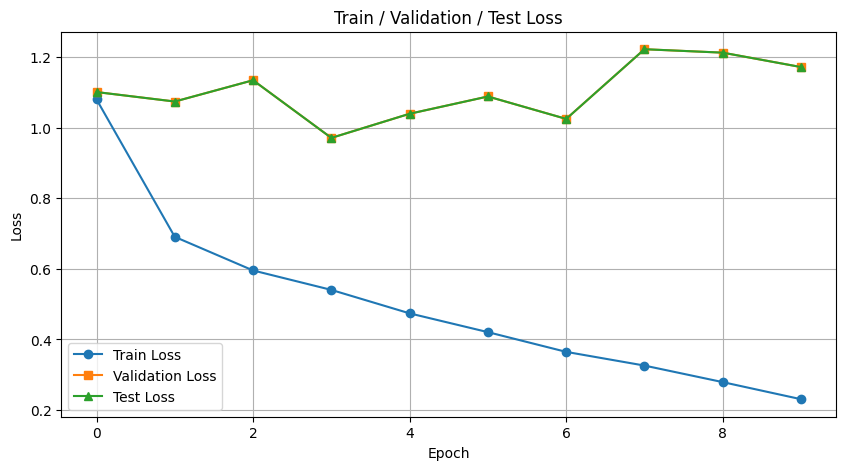

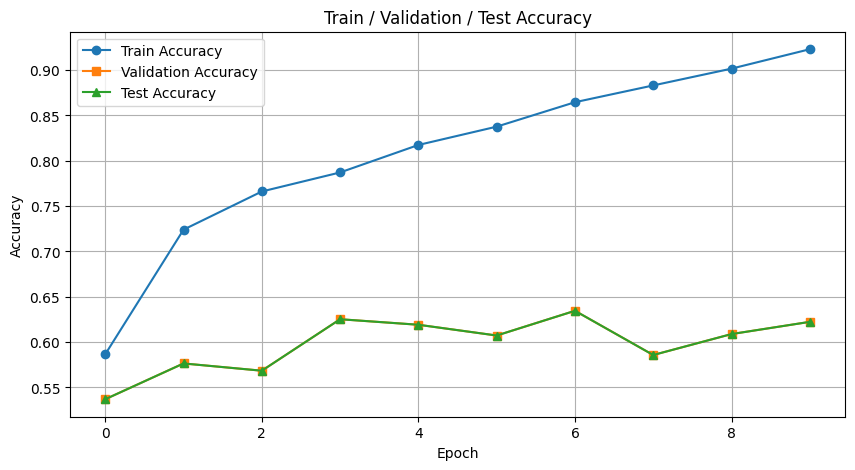

In [ ]:
import matplotlib.pyplot as plt

# ---- Loss Plot ----
plt.figure(figsize=(10,5))
plt.plot(train_loss_list, label="Train Loss", marker='o')
plt.plot(val_loss_list, label="Validation Loss", marker='s')
plt.plot(test_loss_list, label="Test Loss", marker='^')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Train / Validation / Test Loss")
plt.legend()
plt.grid(True)
plt.show()

# ---- Accuracy Plot ----
plt.figure(figsize=(10,5))
plt.plot(train_acc_list, label="Train Accuracy", marker='o')
plt.plot(val_acc_list, label="Validation Accuracy", marker='s')
plt.plot(test_acc_list, label="Test Accuracy", marker='^')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Train / Validation / Test Accuracy")
plt.legend()
plt.grid(True)
plt.show()


Classification Report:
              precision    recall  f1-score   support

           0     0.7314    0.3703    0.4917       478
           1     0.6148    0.9827    0.7564       869
           2     0.8978    0.3241    0.4763       867
           3     0.5354    0.6955    0.6050       903

    accuracy                         0.6224      3117
   macro avg     0.6948    0.5931    0.5823      3117
weighted avg     0.6884    0.6224    0.5940      3117



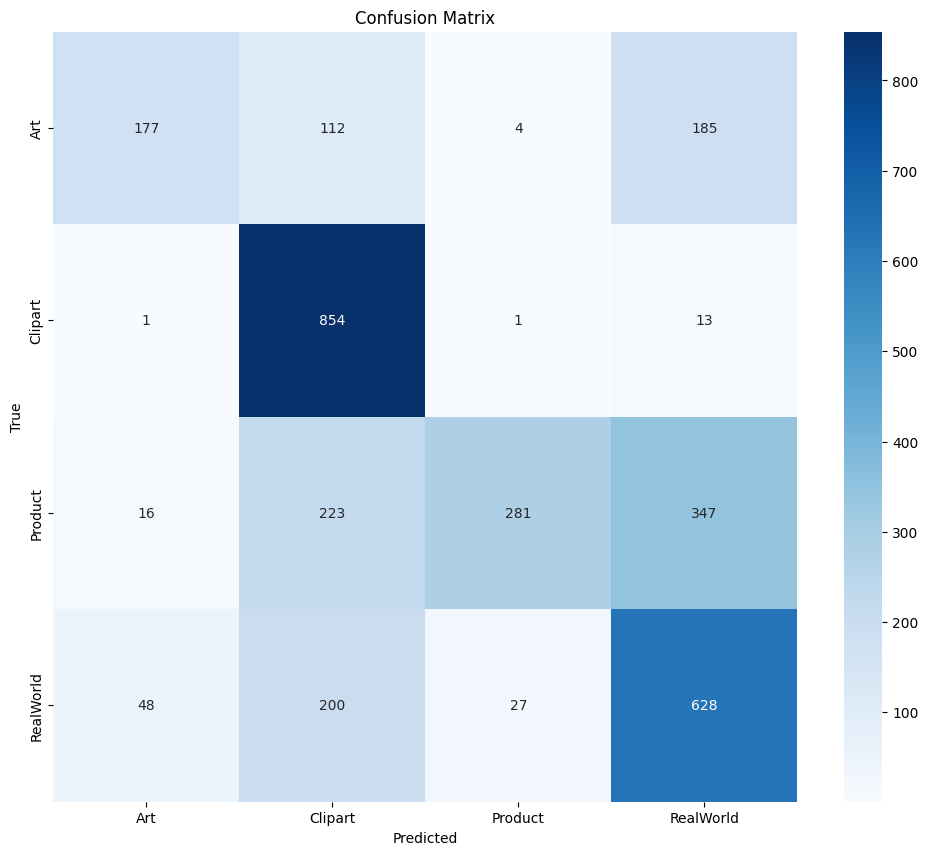

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import torch

# Get all predictions and true labels
all_preds, all_labels = [], []

model.eval()
with torch.no_grad():
    for x, y in test_loader:
        x, y = x.to(device), y.to(device)
        y_hat = model(x)
        preds = y_hat.argmax(1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y.cpu().numpy())

# Classification Report
print("Classification Report:")
print(classification_report(all_labels, all_preds, digits=4))

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)

# Class names for OfficeHome
class_names = ["Art", "Clipart", "Product", "RealWorld"]

plt.figure(figsize=(12,10))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()



#Tuning

##obj

In [28]:

import os
import shutil
import numpy as np
from pathlib import Path
import torch
import torch.nn.functional as F
from tqdm import tqdm
import optuna


def objective_fond(trial, dataset_idx: int = 0):
    """
    Optuna objective function for tuning baseline FOND

    Args:
        trial: Optuna trial object
        dataset_idx: Index into config["dataset"] list

    Returns:
        best_val_acc: Best validation accuracy achieved during training
    """

    # =============================================================================
    # SUGGEST HYPERPARAMETERS
    # =============================================================================

    # FOND-specific hyperparameters
    temperature = trial.suggest_float("temperature", 0.0525, 0.0875)
    xdom_lmbd = trial.suggest_float("xdom_lmbd", 0.1, 1000.0, log=True)
    error_lmbd = trial.suggest_float("error_lmbd", 0.1, 1000.0, log=True)
    xda_alpha = trial.suggest_float("xda_alpha", 1.0, 10.0, log=True)
    xda_beta = trial.suggest_float("xda_beta", 1.0, 10.0, log=True)

    # Standard hyperparameters
    lr = trial.suggest_float("lr", 1e-5, 1e-3, log=True)
    weight_decay = trial.suggest_float("weight_decay", 1e-6, 1e-2, log=True)
    batch_size = trial.suggest_categorical("batch_size", [16, 32, 64])

    coc = config.get("num_domain_linked_classes")
    num_classes = config.get("num_classes")

    # =============================================================================
    # SETUP TRIAL CONFIG
    # =============================================================================

    dataset_name = config["dataset"][dataset_idx]
    test_env = config["test_set_id"]
    backbone = config["backbone"]
    # Calculate steps per epoch based on dataset
    if dataset_name == "PACS":
        steps_per_epoch = int(5000/227)
    elif dataset_name == "VLCS":
        steps_per_epoch = int(5000/147)
    elif dataset_name == "OfficeHome":
        steps_per_epoch =  int(5000/100)
    elif dataset_name == "DomainNet":
        steps_per_epoch = 300
    else:
        steps_per_epoch = 100

    n_steps_trial = steps_per_epoch * 50  # Train for 50 epochs
    checkpoint_freq_trial = steps_per_epoch * 10  # Evaluate every 10 epochs

    # Setup experiment directory
    exp_name = f"optuna_trial_{trial.number}_{dataset_name}_testenv{test_env}_FOND"
    exp_dir = os.path.join(config["log_dir"], "optuna_trials", exp_name)

    exp_dir = Path(exp_dir)
    exp_dir.mkdir(parents=True, exist_ok=True)
    log_dir = exp_dir / 'logs'
    log_dir.mkdir(parents=True, exist_ok=True)

    # =============================================================================
    # RUN TRAINING
    # =============================================================================

    try:
        logger = CSVLogger(log_dir / 'metrics.csv', root_dir=log_dir)

        # Create hparams dict
        hparams = default_hparams(config["algo"], dataset_name)

        # Override with Optuna suggestions
        hparams.update({
            "backbone": "convnext_tiny",
            "pretrained": True,
            "freeze_backbone": True,   # IMPORTANT
            "feature_dim": 768,
            "temperature": temperature,
            "base_temperature": 0.07,
            "xdom_lmbd": xdom_lmbd,
            "error_lmbd": error_lmbd,
            "xda_alpha": xda_alpha,
            "xda_beta": xda_beta,
            "lr": lr,
            "weight_decay": weight_decay,
            "batch_size": batch_size,
        })
        hparams["C_oc"] = coc
        hparams["num_classes"] = num_classes

        print("\n" + "="*60)
        print(f"Trial {trial.number}: FOND Baseline")
        print("="*60)
        print(f"Dataset: {dataset_name}, Test Env: {test_env}")
        print(f"Training for {n_steps_trial} steps ({n_steps_trial//steps_per_epoch} epochs)")
        print("-"*60)
        print("FOND Hyperparameters:")
        print(f"  temperature:  {temperature:.4f}")
        print(f"  xdom_lmbd:    {xdom_lmbd:.2e}")
        print(f"  error_lmbd:   {error_lmbd:.2e}")
        print(f"  xda_alpha:    {xda_alpha:.2f}")
        print(f"  xda_beta:     {xda_beta:.2f}")
        print(f"backbone:     {backbone}")
        print("-"*60)
        print("Training Hyperparameters:")
        print(f"  lr:           {lr:.2e}")
        print(f"  weight_decay: {weight_decay:.2e}")
        print(f"  batch_size:   {batch_size}")
        print("="*60 + "\n")

        # Create dataset
        dataset = DATASETS[dataset_name](
            root=config["data_dir"][dataset_name],
            test_envs=[test_env],
            hparams=hparams,
            overlap_type=config["overlap"],
            num_classes=config["num_classes"],
            num_domain_linked_classes=config["num_domain_linked_classes"],
            # use_randaugment=False
        )

        # Run training
        best_val_acc = run_trial_training_fond(
            trial=trial,
            dataset=dataset,
            hparams=hparams,
            config=config,
            exp_dir=exp_dir,
            logger=logger,
            n_steps=n_steps_trial,
            checkpoint_freq=checkpoint_freq_trial
        )

        # Clean up to save disk space
        if os.path.exists(exp_dir):
            shutil.rmtree(exp_dir)

        return best_val_acc

    except Exception as e:
        print(f"❌ Trial {trial.number} failed: {e}")
        import traceback
        traceback.print_exc()
        return 0.0

## run

In [24]:

def run_trial_training_fond(trial, dataset, hparams, config, exp_dir, logger, n_steps, checkpoint_freq):
    """
    Simplified training loop for FOND Optuna trials

    Args:
        trial: Optuna trial object
        dataset: MultipleDomainDataset instance
        hparams: Dictionary of hyperparameters
        config: Global config dictionary
        exp_dir: Experiment directory path
        logger: CSVLogger instance
        n_steps: Total training steps
        checkpoint_freq: Steps between evaluations

    Returns:
        best_test_acc: Best test accuracy achieved
    """
    import torch
    import torch.nn.functional as F
    import collections
    from tqdm import tqdm

    device = "cuda" if torch.cuda.is_available() else "cpu"
    dataset_name = config["dataset"][0]
    test_env = config["test_set_id"]
    algorithm_name = "FOND"

    # =============================================================================
    # DATA SPLITTING
    # =============================================================================

    in_splits = []
    out_splits = []
    relative_test_env = None

    for env_i, env in enumerate(dataset):
        # Split each domain into in-split (train) and out-split (validation)
        out, in_ = split_dataset(
            env,
            int(len(env) * config["holdout_fraction"]),
            seed_hash(config["trial_id"], env_i)
        )

        in_splits.append((in_, None))
        out_splits.append((out, None))

        if env.is_test_env:
            relative_test_env = env_i

    # =============================================================================
    # CREATE DATA LOADERS
    # =============================================================================

    # Training loaders (only source domains, not test domain)
    train_loaders = [
        InfiniteDataLoader(
            dataset=env,
            weights=None,
            batch_size=hparams["batch_size"],
            num_workers=12,
        )
        for i, (env, _) in enumerate(in_splits)
        if i != relative_test_env
    ]

    # Evaluation loaders (all domains, both in-split and out-split)
    eval_loaders = [
        FastDataLoader(
            dataset=env,
            batch_size=hparams["batch_size"],
            num_workers=12,
        )
        for env, _ in (in_splits + out_splits)
    ]

    # Names for evaluation loaders
    eval_loader_names = ["env{}_in".format(i) for i in range(len(in_splits))]
    eval_loader_names += ["env{}_out".format(i) for i in range(len(out_splits))]

    # Create iterator for training
    train_minibatches_iterator = zip(*train_loaders)

    # =============================================================================
    # SETUP ALGORITHM
    # =============================================================================

    algorithm = ALGORITHMS[algorithm_name](
        input_shape=dataset.input_shape,
        num_classes=dataset.num_classes,
        num_domains=len(dataset) - 1,  # Exclude test domain
        hparams=hparams,
    )
    algorithm.to(device)

    # =============================================================================
    # TRAINING LOOP
    # =============================================================================

    best_test_acc = 0.0

    for step in tqdm(range(n_steps), desc=f"Trial {trial.number} [FOND]"):
        # Get minibatches from all training domains
        minibatches_device = [
            (x.to(device), y.to(device))
            for x, y in next(train_minibatches_iterator)
        ]

        # Update algorithm (forward + backward + optimizer step)
        step_vals = algorithm.update(minibatches_device, None)

        # =============================================================================
        # EVALUATION
        # =============================================================================

        if (step % checkpoint_freq == 0) or (step == n_steps - 1):
            results_dict = {"test": {"acc": []}}

            # Evaluate on all loaders
            for name, loader in zip(eval_loader_names, eval_loaders):
                acc, recall, f1, precision, oacc, nacc, per_class_acc, cm = accuracy(
                    algorithm, loader, None, device, dataset
                )

                domain_idx = int(name[3])

                # Collect TEST domain performance (in-split only)
                # This is the held-out domain that the model has never seen
                if domain_idx == relative_test_env and "in" in name:
                    results_dict["test"]["acc"].append(float(acc))

            # Calculate average test accuracy
            if results_dict["test"]["acc"]:
                current_test_acc = np.mean(results_dict["test"]["acc"])

                # Update best accuracy
                if current_test_acc > best_test_acc:
                    best_test_acc = current_test_acc

                # Report to Optuna for pruning
                trial.report(current_test_acc, step)

                # Check if trial should be pruned
                if trial.should_prune():
                    raise optuna.TrialPruned()

                # Optional: Print progress
                if step % (checkpoint_freq * 5) == 0:  # Print every 50 epochs
                    print(f"  [Step {step}/{n_steps}] Test Acc: {current_test_acc:.2%} (Best: {best_test_acc:.2%})")

    # =============================================================================
    # CLEANUP
    # =============================================================================

    del train_loaders
    del eval_loaders
    del train_minibatches_iterator
    torch.cuda.empty_cache()

    print(f"\n✅ Trial {trial.number} completed: Best Test Acc = {best_test_acc:.2%}\n")

    return best_test_acc

##OH

### tuning

In [32]:
# Create Optuna study
import optuna
from optuna.pruners import MedianPruner
from pathlib import Path

study = optuna.create_study(
    direction="maximize",
    pruner=MedianPruner(n_startup_trials=5, n_warmup_steps=50)
)

# Run optimization
n_trials = 20 # Adjust based on your compute budget

print(f"Starting Optuna optimization with {n_trials} trials...")
print(f"Dataset: {config['dataset'][0]}, Test Env: {config['test_set_id']}")
print(f"Optimizing: val/oacc (domain-shared class accuracy)\n")


study.optimize(lambda trial: objective_fond(trial,0), n_trials=n_trials)

print("\n" + "="*60)
print("OPTIMIZATION COMPLETE!")
print("="*60)
print(f"\nBest val/oacc: {study.best_value:.4f}")
print(f"\nBest Hyperparameters:")
for key, value in study.best_params.items():
    print(f"  {key}: {value}")

[I 2026-02-08 12:44:58,806] A new study created in memory with name: no-name-9f110986-34f6-49e6-b26f-edbdf3099826


Starting Optuna optimization with 20 trials...
Dataset: OfficeHome, Test Env: 0
Optimizing: val/oacc (domain-shared class accuracy)


Trial 0: FOND Baseline
Dataset: OfficeHome, Test Env: 0
Training for 2500 steps (50 epochs)
------------------------------------------------------------
FOND Hyperparameters:
  temperature:  0.0664
  xdom_lmbd:    2.04e+02
  error_lmbd:   3.92e-01
  xda_alpha:    5.48
  xda_beta:     6.52
backbone:     convnext_tiny
------------------------------------------------------------
Training Hyperparameters:
  lr:           4.94e-04
  weight_decay: 7.08e-03
  batch_size:   16

[OfficeHome] overlap_type = high
[OfficeHome] domain_class_filter = [[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37], [5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43], [27, 28, 29, 30, 31, 32, 

Trial 0 [FOND]:   0%|          | 1/2500 [00:36<25:36:34, 36.89s/it]

  [Step 0/2500] Test Acc: 1.57% (Best: 1.57%)


Trial 0 [FOND]: 100%|██████████| 2500/2500 [11:06<00:00,  3.75it/s]


...

  [Step 0/2500] Test Acc: 1.50% (Best: 1.50%)


Trial 19 [FOND]:  40%|████      | 1000/2500 [12:19<18:29,  1.35it/s]
Traceback (most recent call last):
  File "/tmp/ipython-input-3029534823.py", line 134, in objective_fond
    best_val_acc = run_trial_training_fond(
                   ^^^^^^^^^^^^^^^^^^^^^^^^
  File "/tmp/ipython-input-1219732332.py", line 144, in run_trial_training_fond
    raise optuna.TrialPruned()
optuna.exceptions.TrialPruned


❌ Trial 19 failed: 


[I 2026-02-08 18:00:30,846] Trial 19 finished with value: 0.0 and parameters: {'temperature': 0.0655196515359166, 'xdom_lmbd': 0.11198515734914873, 'error_lmbd': 1.5931329141324773, 'xda_alpha': 6.959531428591826, 'xda_beta': 2.169102094462328, 'lr': 5.570996938542549e-05, 'weight_decay': 3.674413399184258e-05, 'batch_size': 64}. Best is trial 4 with value: 0.7090890407562256.



OPTIMIZATION COMPLETE!

Best val/oacc: 0.7091

Best Hyperparameters:
  temperature: 0.05806267550007497
  xdom_lmbd: 4.6620905200273155
  error_lmbd: 0.1368916207983103
  xda_alpha: 3.4888418339169354
  xda_beta: 7.189719965066721
  lr: 3.0156610365320048e-05
  weight_decay: 2.1284711395696195e-06
  batch_size: 32


### training

eee


INFO: Seed set to 0
INFO:lightning.fabric.utilities.seed:Seed set to 0


OfficeHome

HYPERPARAMETERS AFTER CONFIG OVERRIDE:
  backbone: convnext_tiny
  base_temperature: 0.07
  batch_size: 32
  class_balanced: False
  data_augmentation: True
  error_lmbd: 0.1368916207983103
  lr: 3.0156610365320048e-05
  nonlinear_classifier: False
  resnet18: True
  resnet_dropout: 0.0
  temperature: 0.07
  weight_decay: 2.1284711395696195e-06
  xda_alpha: 3.4888418339169354
  xda_beta: 7.189719965066721
  xdom_lmbd: 4.6620905200273155

[OfficeHome] overlap_type = high
[OfficeHome] domain_class_filter = [[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37], [5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43], [27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64]]
[OfficeHome] num source do

  0%|          | 0/5001 [00:56<?, ?it/s]


=== Step 0 (Epoch 0.00) ===
step_time: 56.5119s
TRAIN:
  loss: 11.8892
  acc: 0.0063
  precision: 0.0087
  recall: 0.0063
  f1: 0.0062
  oacc: 0.0079
  nacc: 0.0037
VAL:
  loss: 4.2517
  acc: 0.0098
  precision: 0.0169
  recall: 0.0098
  f1: 0.0094
  oacc: 0.0089
  nacc: 0.0107
TEST:
  loss: 4.2573
  acc: 0.0122
  precision: 0.0103
  recall: 0.0122
  f1: 0.0102
  oacc: 0.0095
  nacc: 0.0163
OTHER:
  loss: 4.2507
  acc: 0.0164
  precision: 0.0222
  recall: 0.0164
  f1: 0.0175
  oacc: 0.0060
  nacc: 0.0321


...


=== Step 4000 (Epoch 65.91) ===
step_time: 39.7333s
TRAIN:
  loss: 1.6707
  acc: 0.9603
  precision: 0.9617
  recall: 0.9603
  f1: 0.9609
  oacc: 0.7575
  nacc: 0.3287
VAL:
  loss: 0.3543
  acc: 0.7959
  precision: 0.8097
  recall: 0.7959
  f1: 0.8001
  oacc: 0.7021
  nacc: 0.2868
TEST:
  loss: 1.0416
  acc: 0.7086
  precision: 0.7425
  recall: 0.7086
  f1: 0.7041
  oacc: 0.7651
  nacc: 0.6239
OTHER:
  loss: 0.8833
  acc: 0.7161
  precision: 0.7532
  recall: 0.7161
  f1: 0.7125
  oacc: 0.7571
  nacc: 0.6546


 90%|█████████ | 4501/5001 [34:08<1:43:19, 12.40s/it]


=== Step 4500 (Epoch 74.15) ===
step_time: 40.3821s
TRAIN:
  loss: 1.6267
  acc: 0.9691
  precision: 0.9699
  recall: 0.9691
  f1: 0.9694
  oacc: 0.7574
  nacc: 0.3293
VAL:
  loss: 0.3380
  acc: 0.7741
  precision: 0.7924
  recall: 0.7741
  f1: 0.7798
  oacc: 0.7020
  nacc: 0.2876
TEST:
  loss: 1.0623
  acc: 0.7055
  precision: 0.7426
  recall: 0.7055
  f1: 0.7013
  oacc: 0.7610
  nacc: 0.6223
OTHER:
  loss: 0.9417
  acc: 0.7223
  precision: 0.7577
  recall: 0.7223
  f1: 0.7201
  oacc: 0.7850
  nacc: 0.6284


100%|██████████| 5001/5001 [37:50<00:00,  2.20it/s]



=== Step 5000 (Epoch 82.39) ===
step_time: 40.5305s
TRAIN:
  loss: 1.5787
  acc: 0.9871
  precision: 0.9871
  recall: 0.9871
  f1: 0.9870
  oacc: 0.7576
  nacc: 0.3311
VAL:
  loss: 0.3528
  acc: 0.7940
  precision: 0.8088
  recall: 0.7940
  f1: 0.7986
  oacc: 0.7055
  nacc: 0.2914
TEST:
  loss: 1.1209
  acc: 0.7015
  precision: 0.7413
  recall: 0.7015
  f1: 0.6937
  oacc: 0.7593
  nacc: 0.6147
OTHER:
  loss: 0.9547
  acc: 0.7020
  precision: 0.7293
  recall: 0.7020
  f1: 0.6950
  oacc: 0.7465
  nacc: 0.6352

TRAINING COMPLETED
Total training time: 2270.32s (37.84 minutes)
Average time per epoch: 27.26s
Total epochs: 81
Best model saved: /kaggle/working/experiments/eee/logs/best_model_convnext_tiny.pt


FINAL EVALUATION - CONFUSION MATRICES

TEST - env0_in:
  Loss: 1.1206
  Accuracy: 0.7015, Precision: 0.7413, Recall: 0.7015, F1: 0.6937
  Confusion Matrix:
[[62  0  0 ...  0  0  0]
 [ 0 27  0 ...  1  0  0]
 [ 0  1 19 ...  0  0  0]
 ...
 [ 0  1  0 ... 11  0  0]
 [ 0  0  2 ...  0 10  0]
 

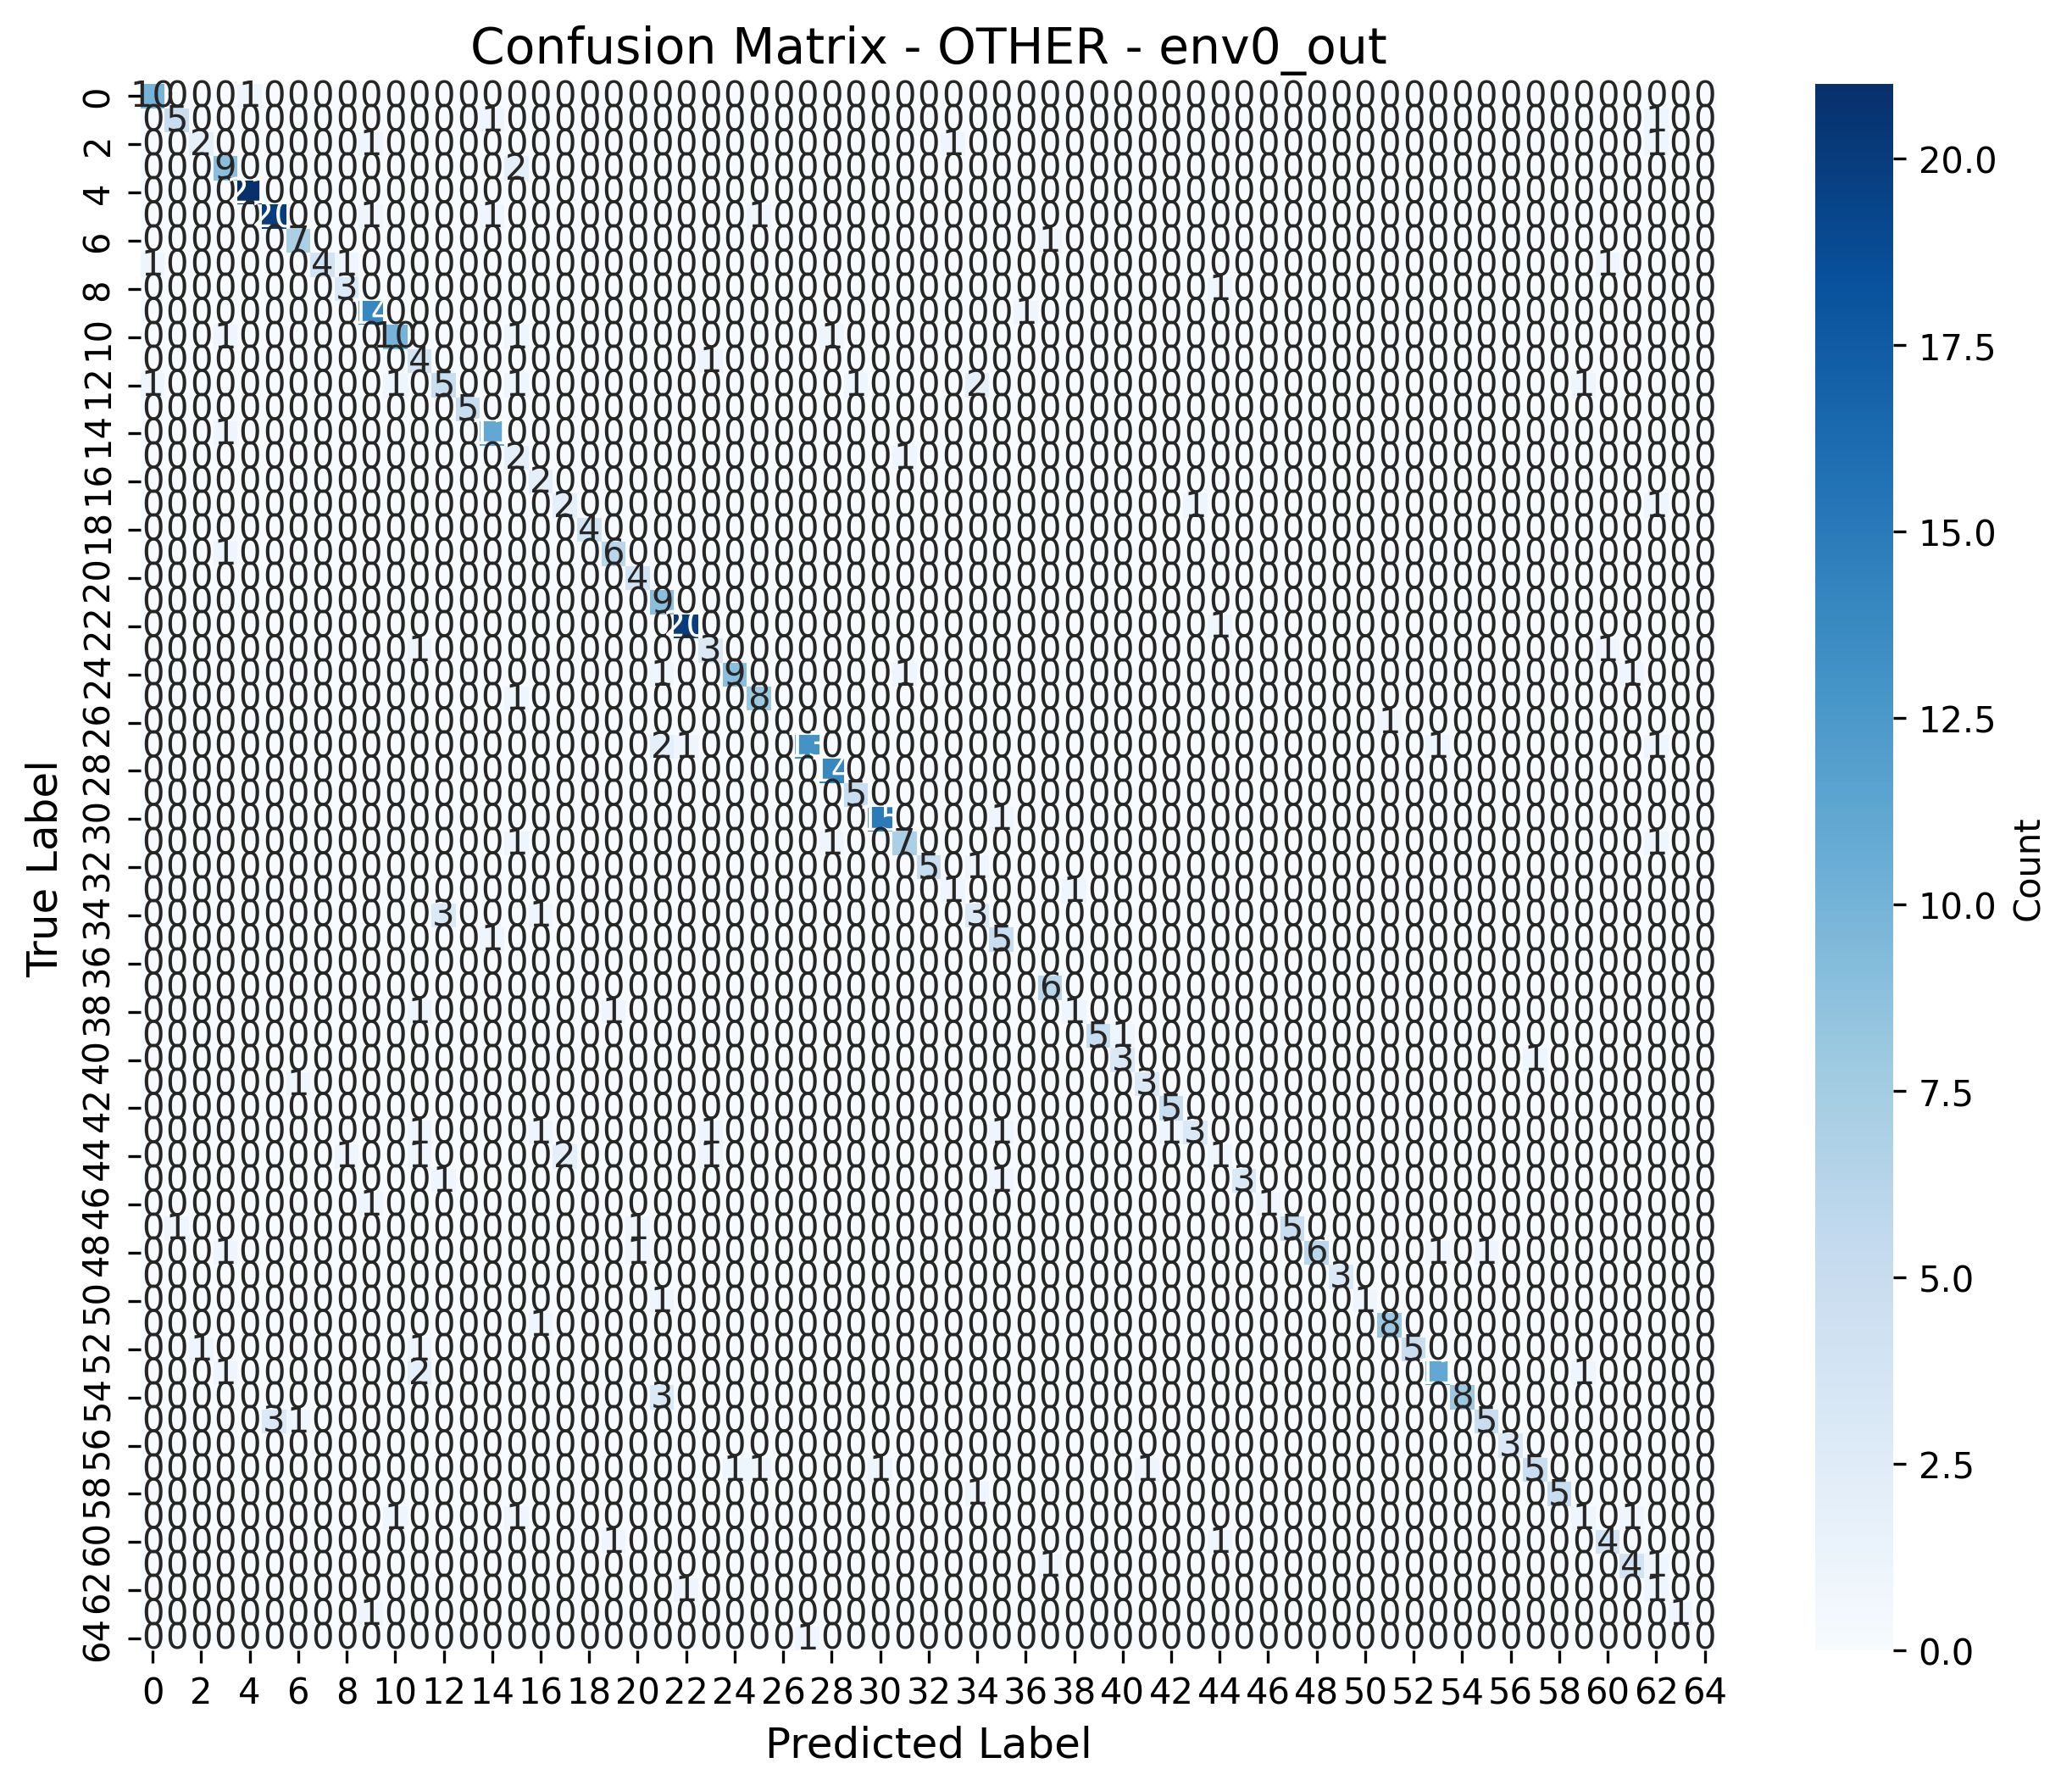


confusion_matrix_TEST_env0_in.png


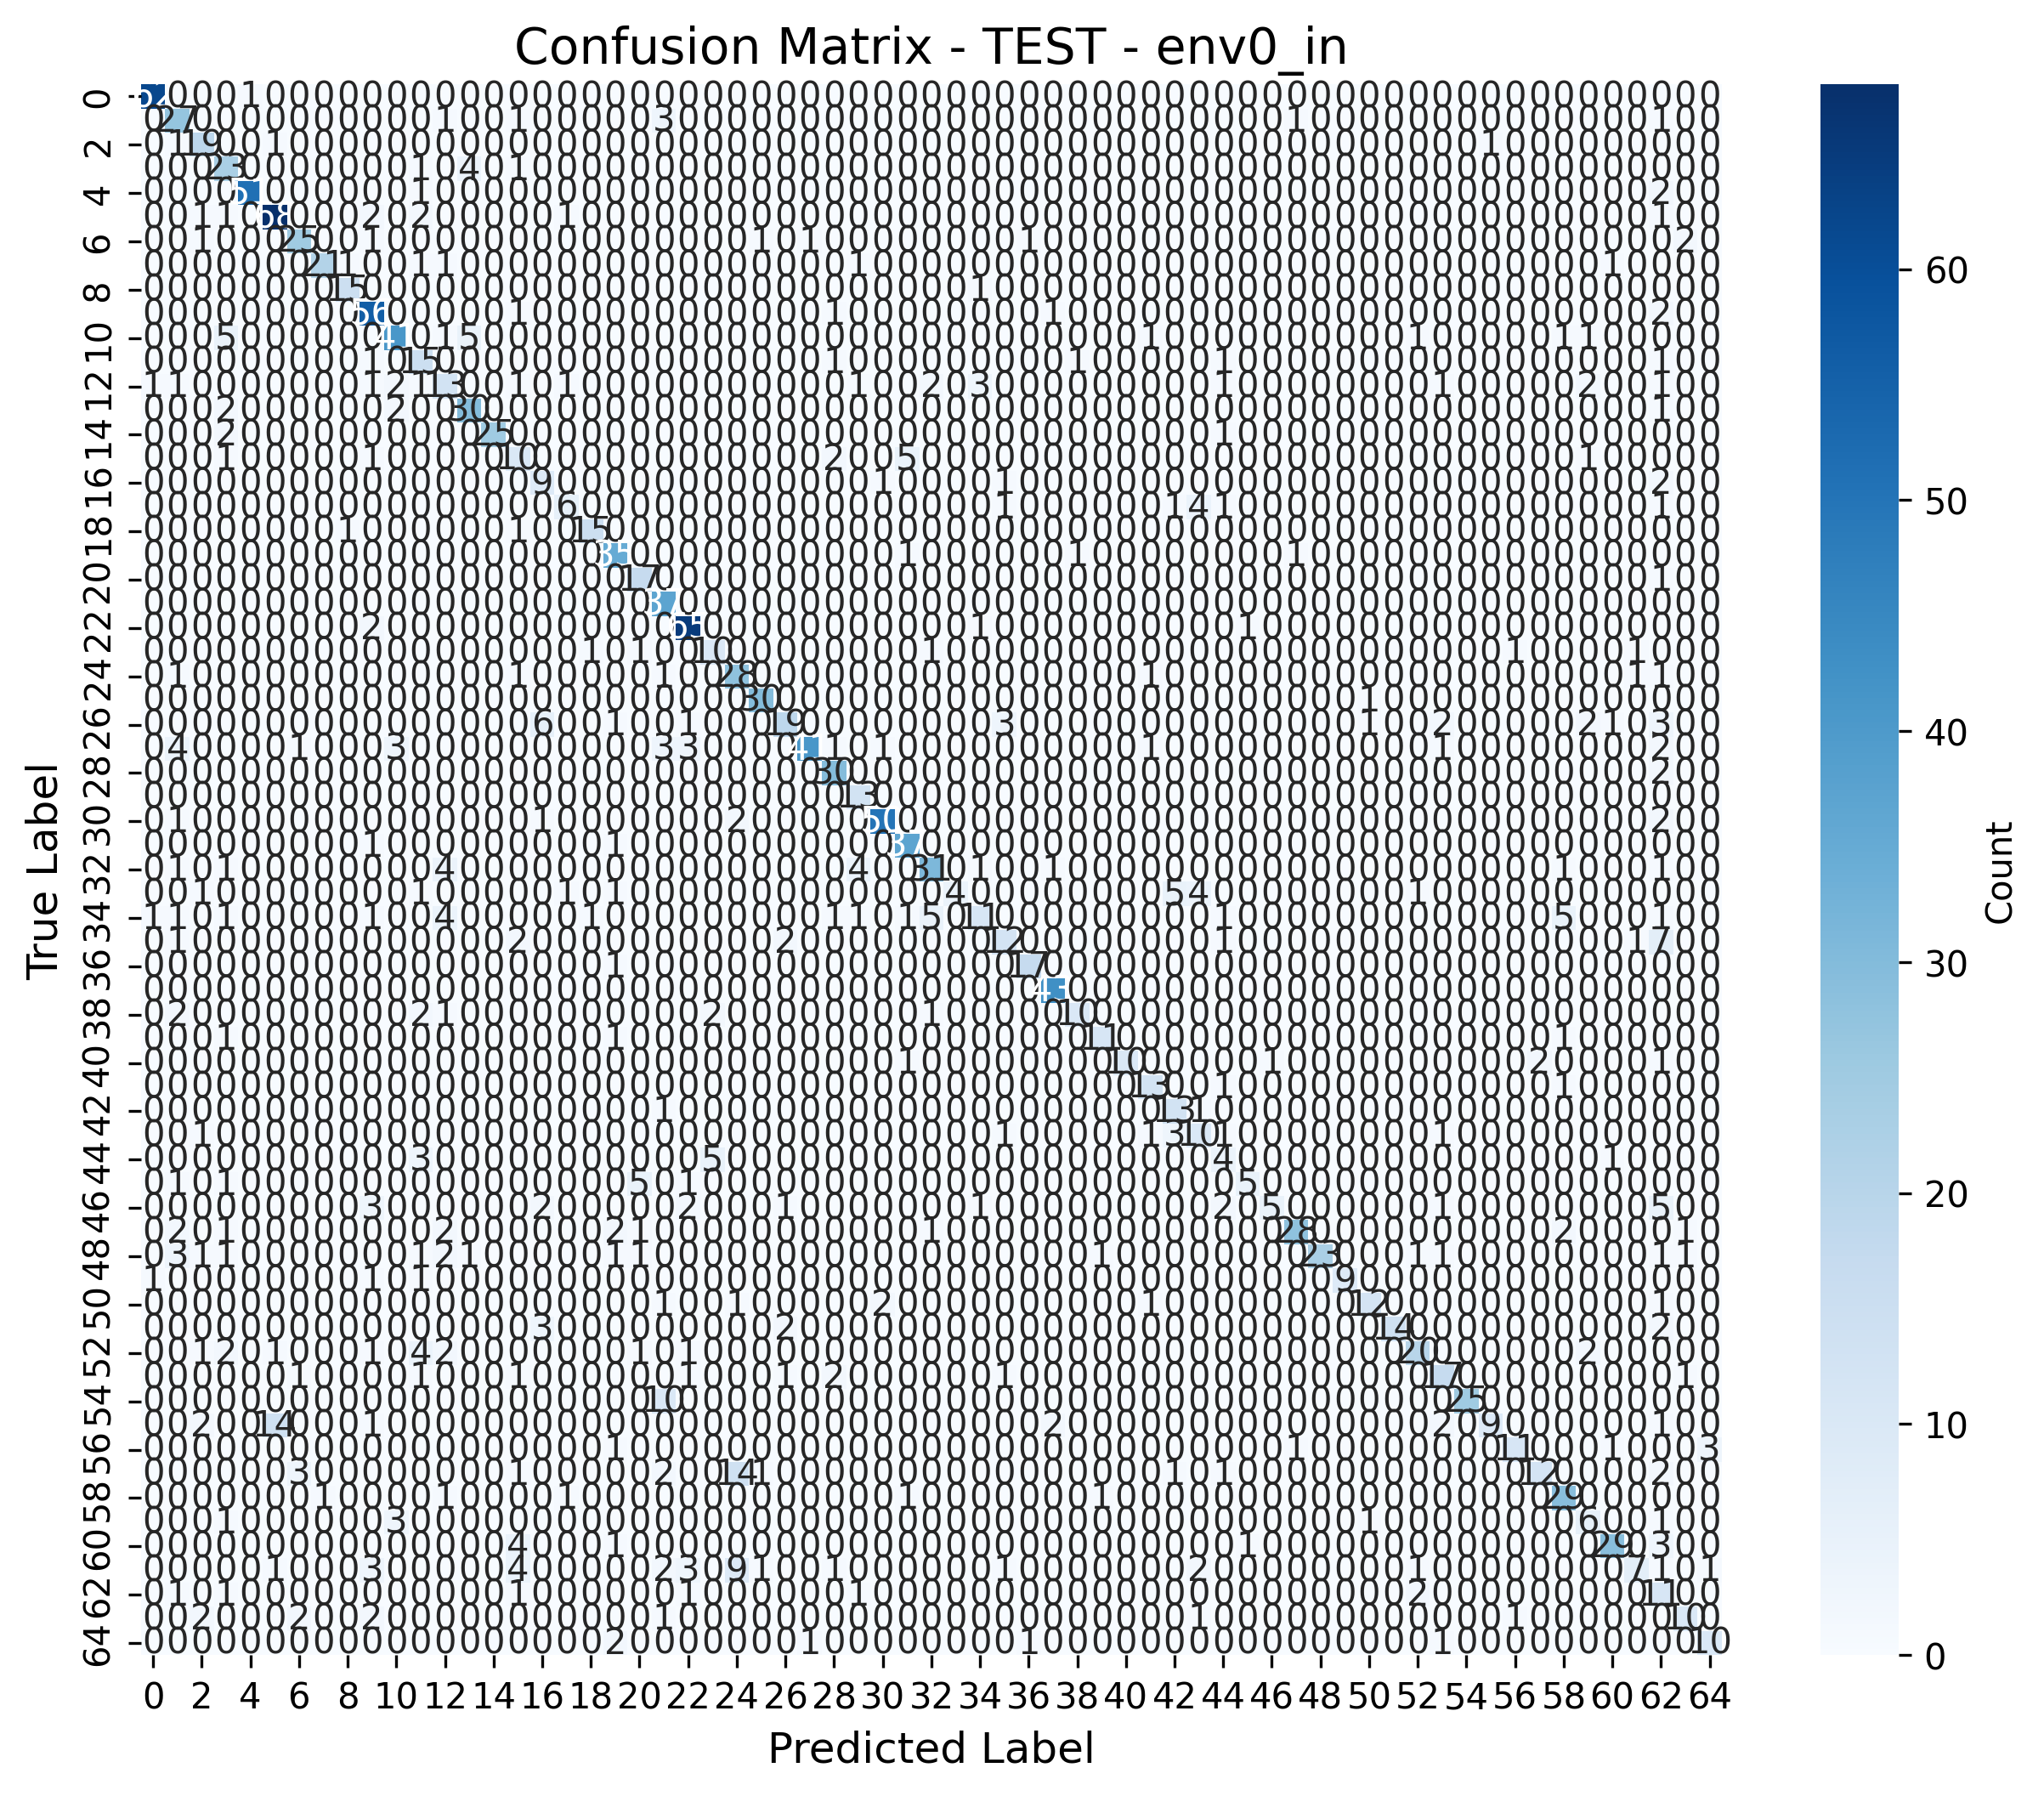


confusion_matrix_TRAIN_env1_in.png


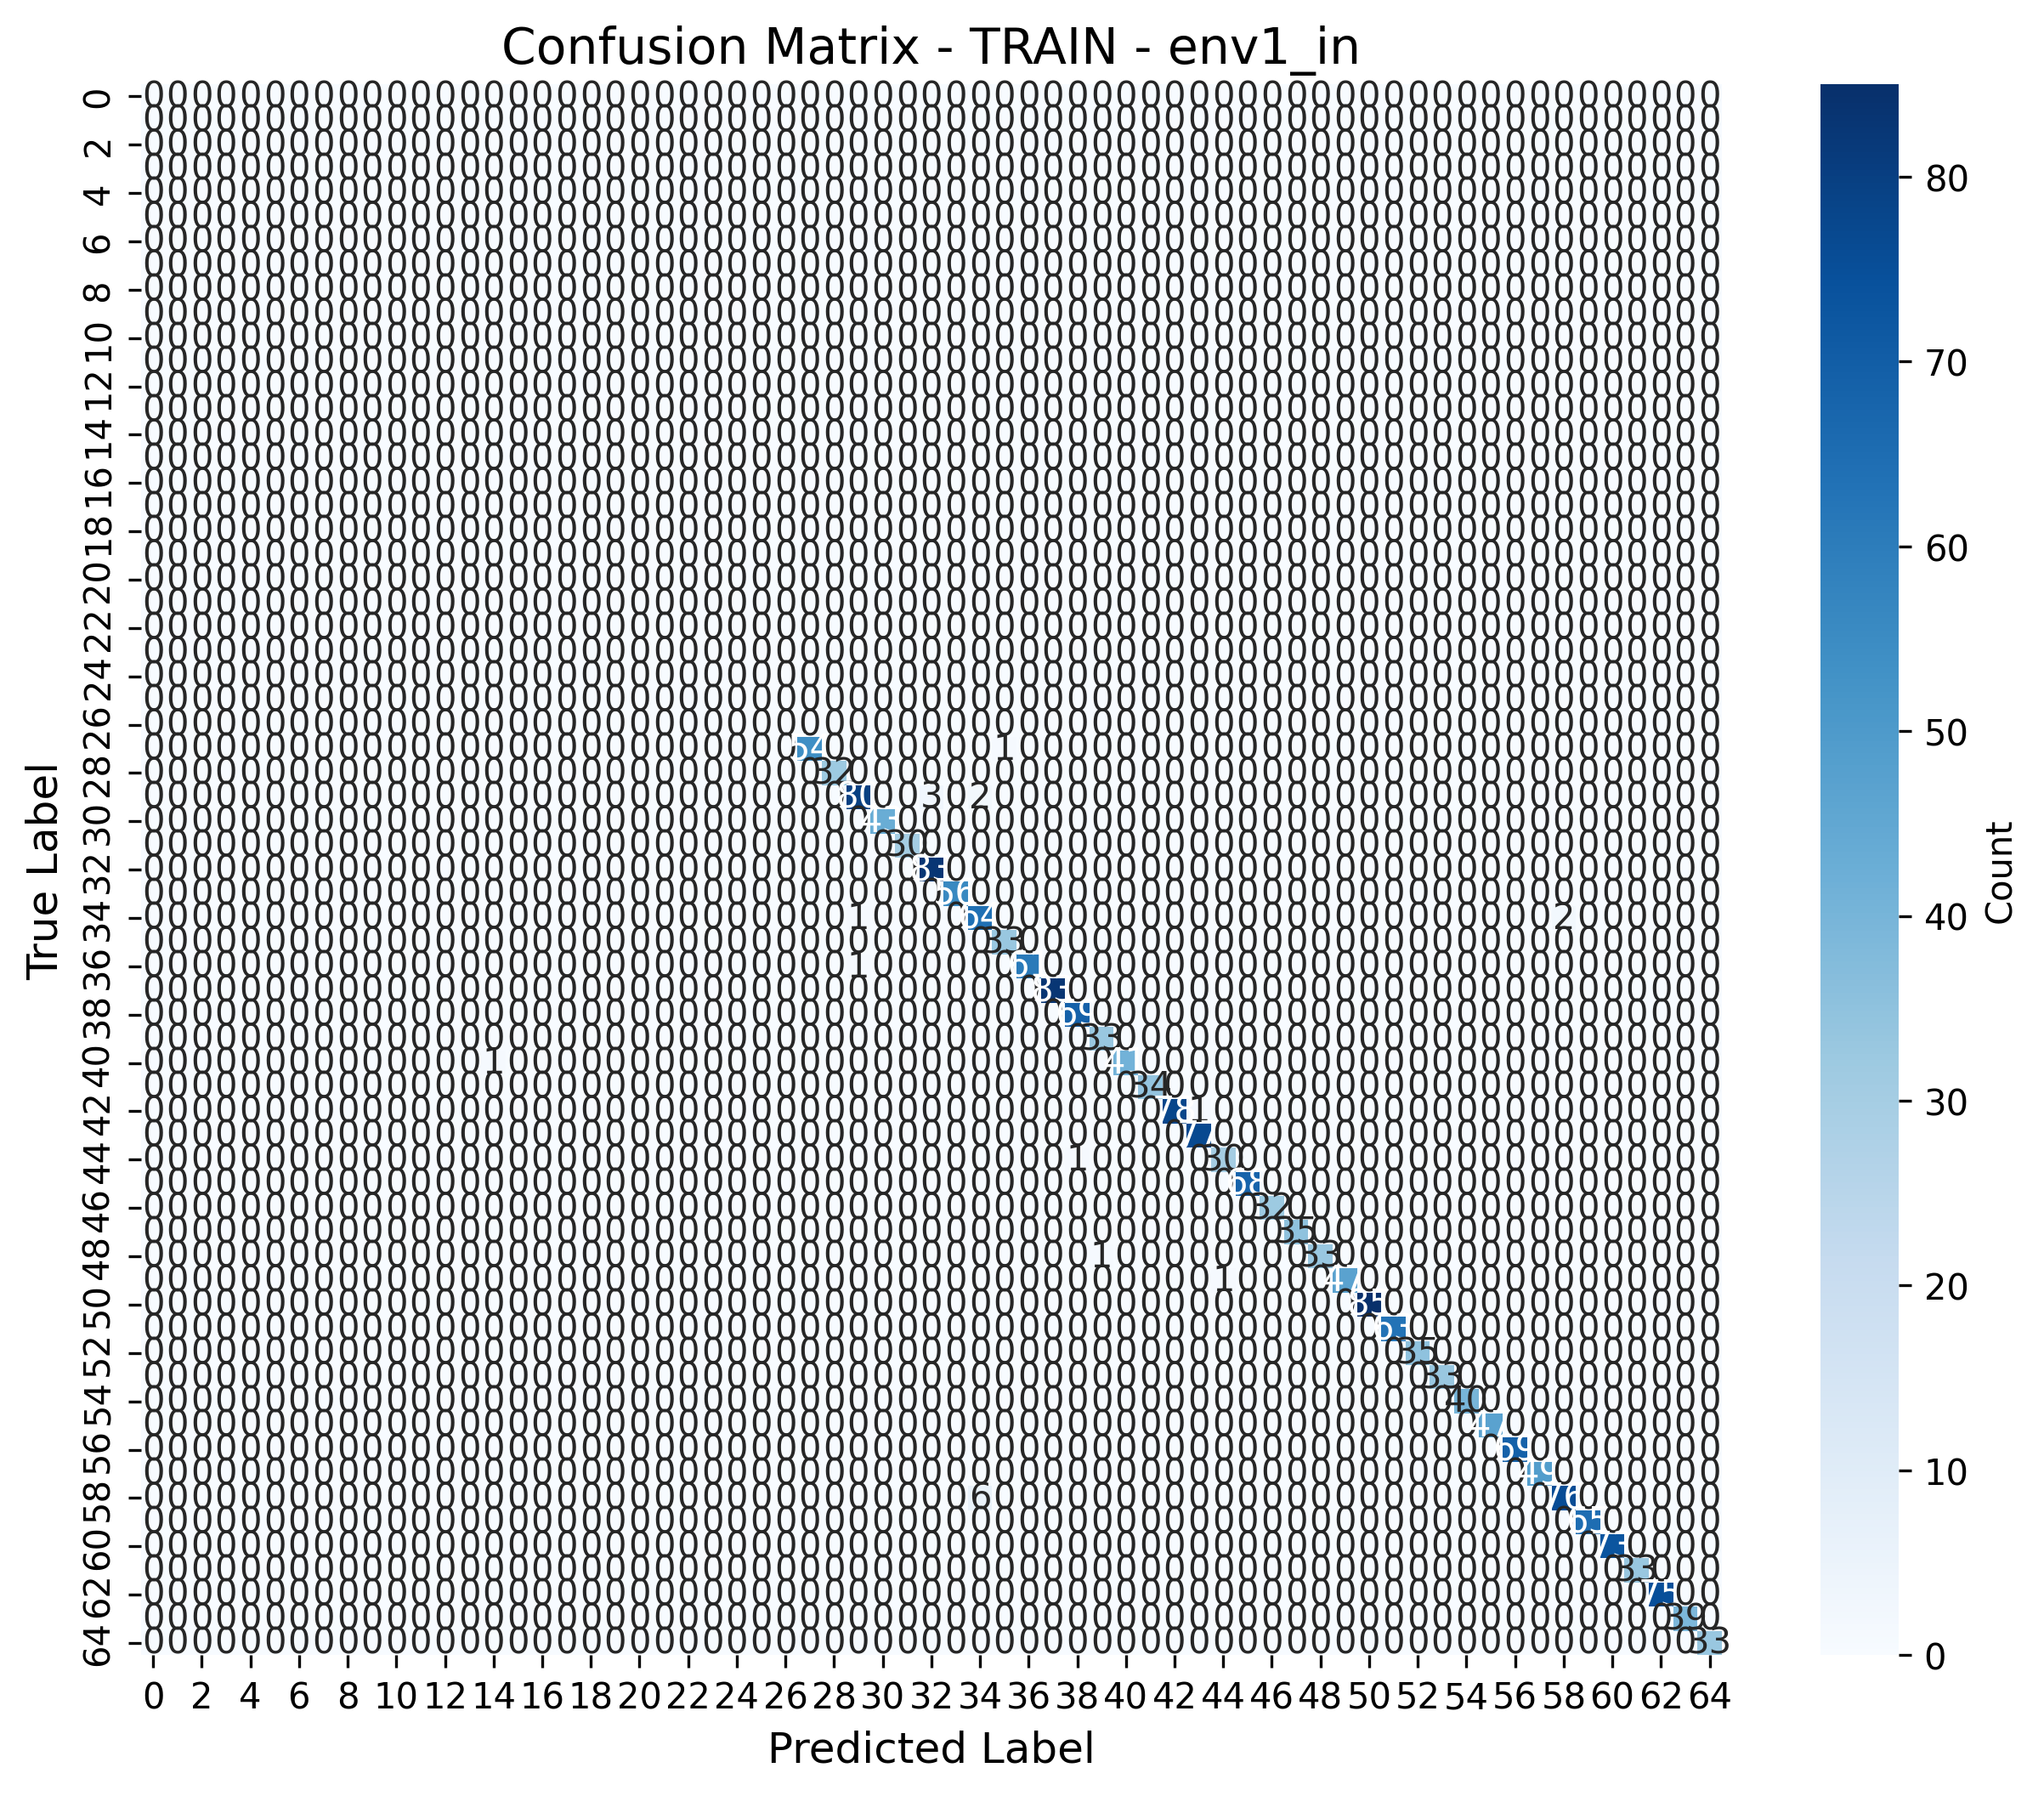


confusion_matrix_TRAIN_env2_in.png


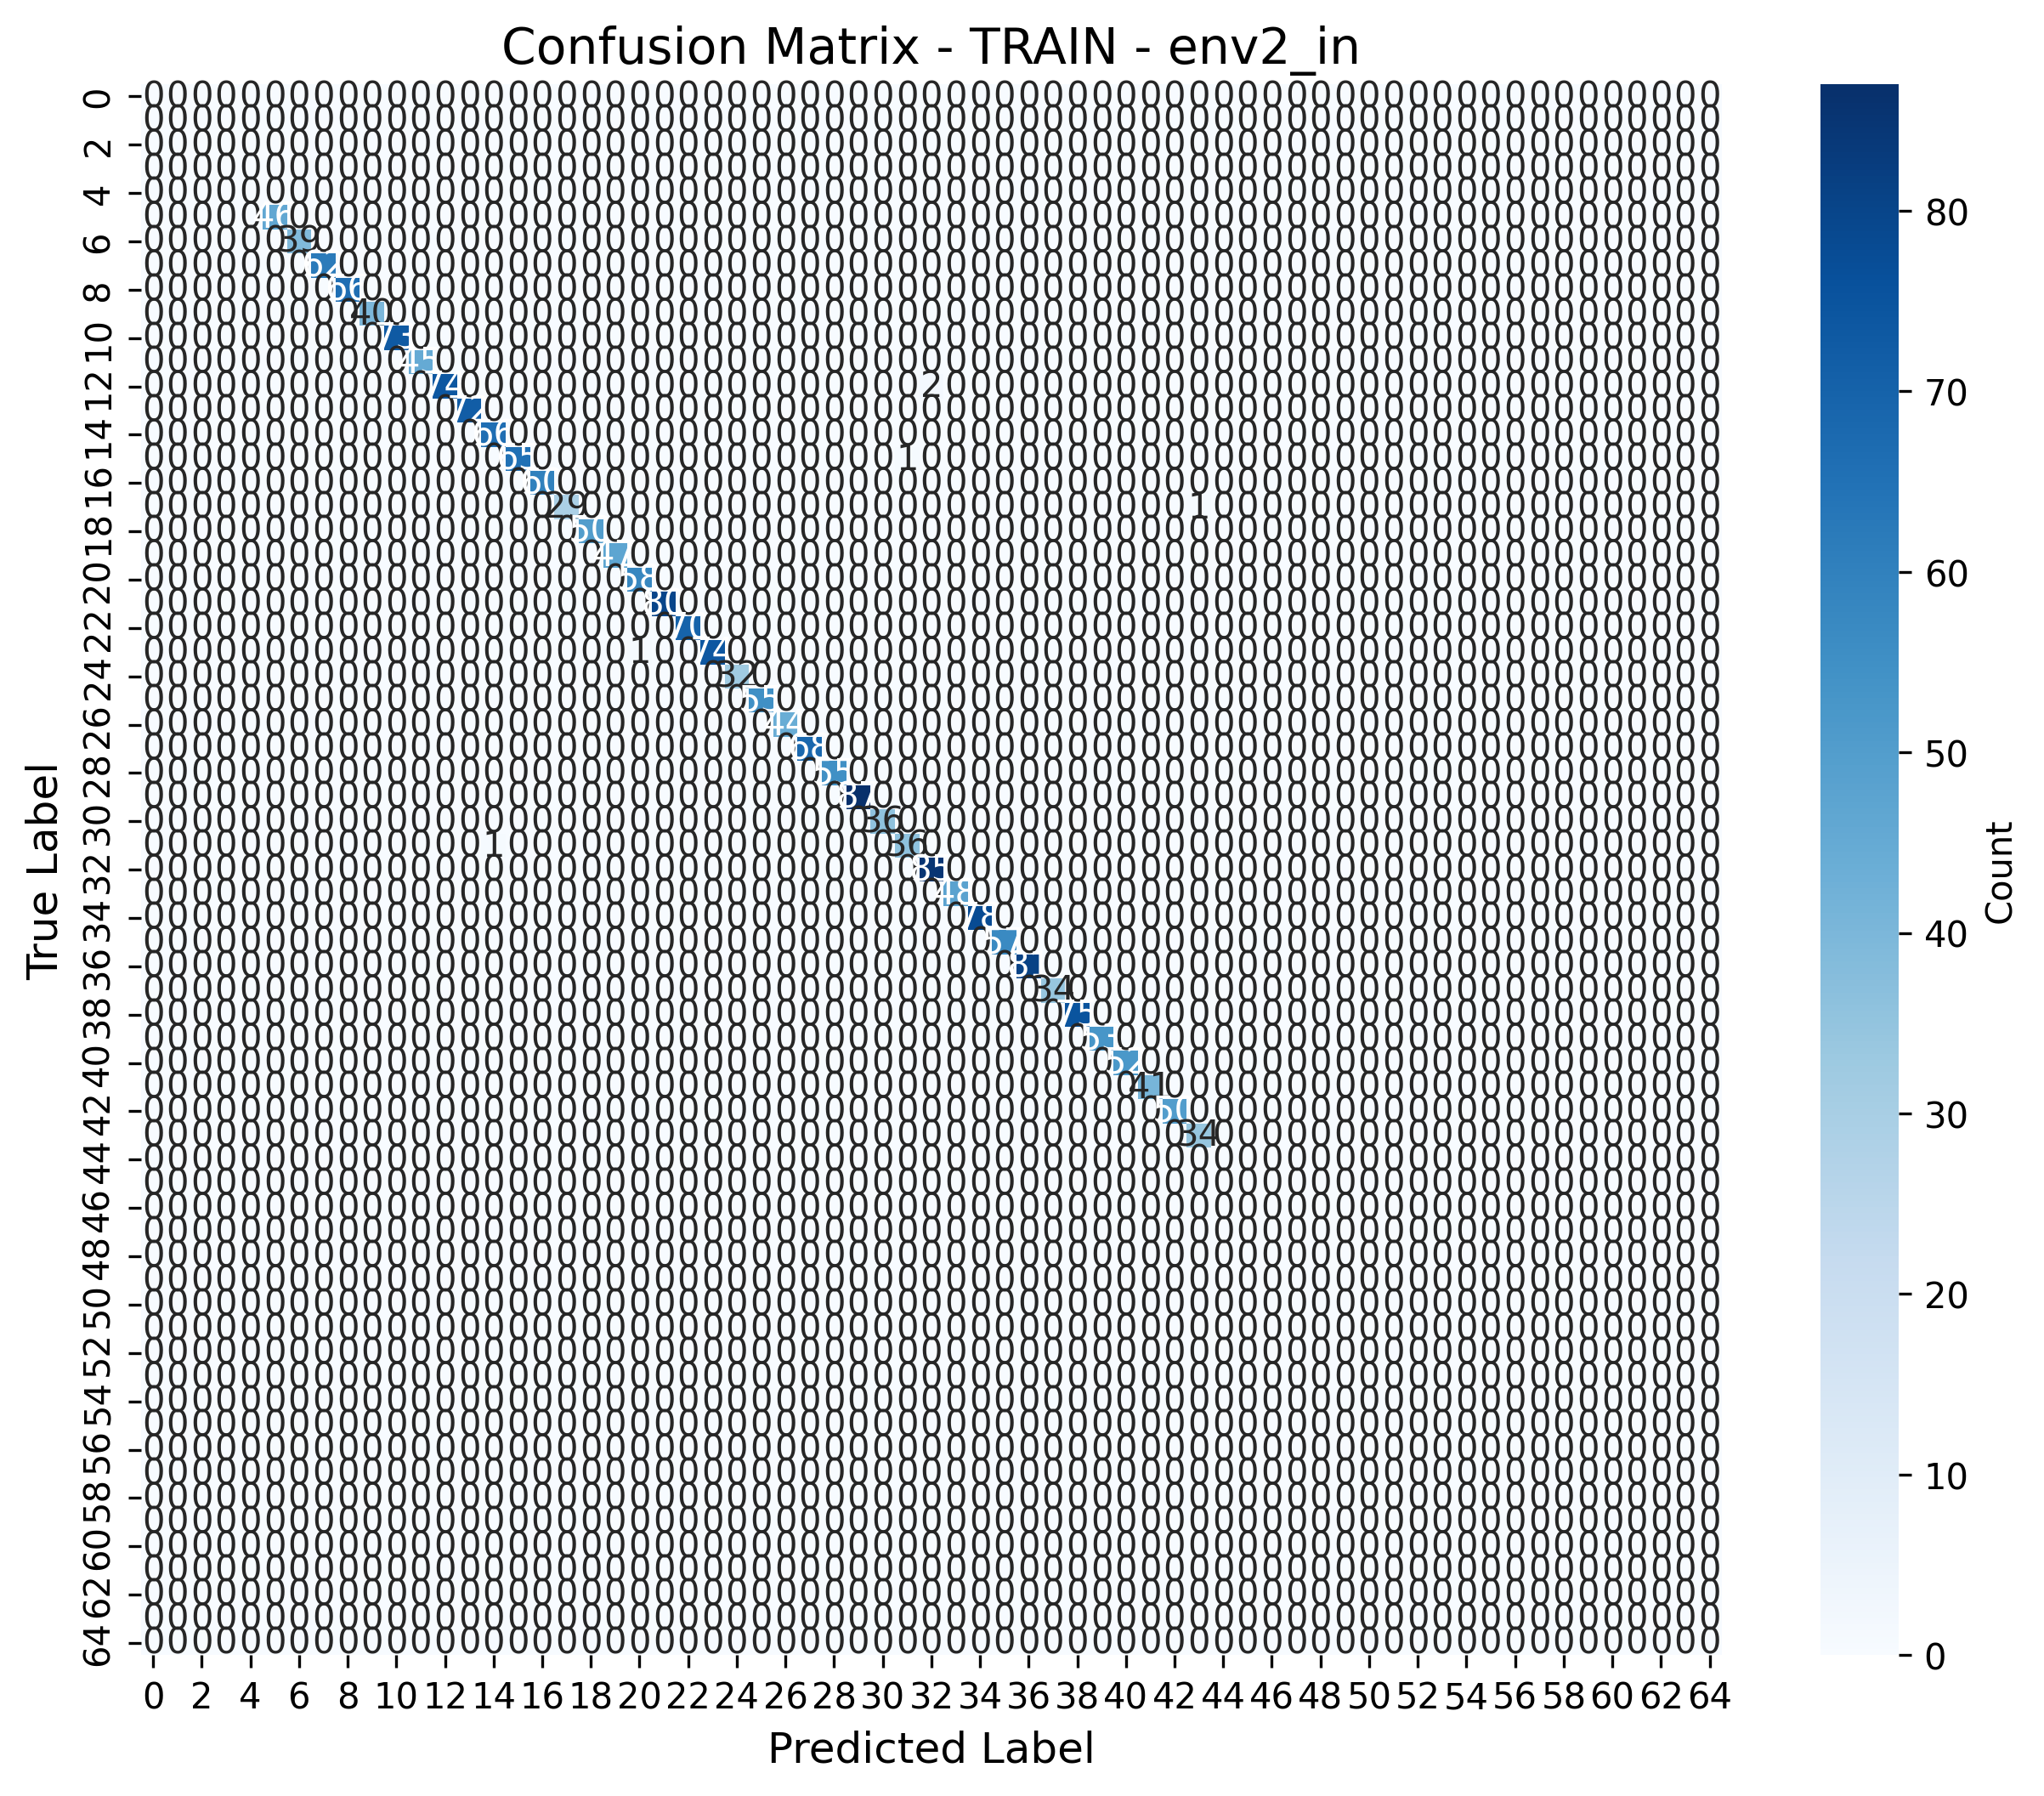


confusion_matrix_TRAIN_env3_in.png


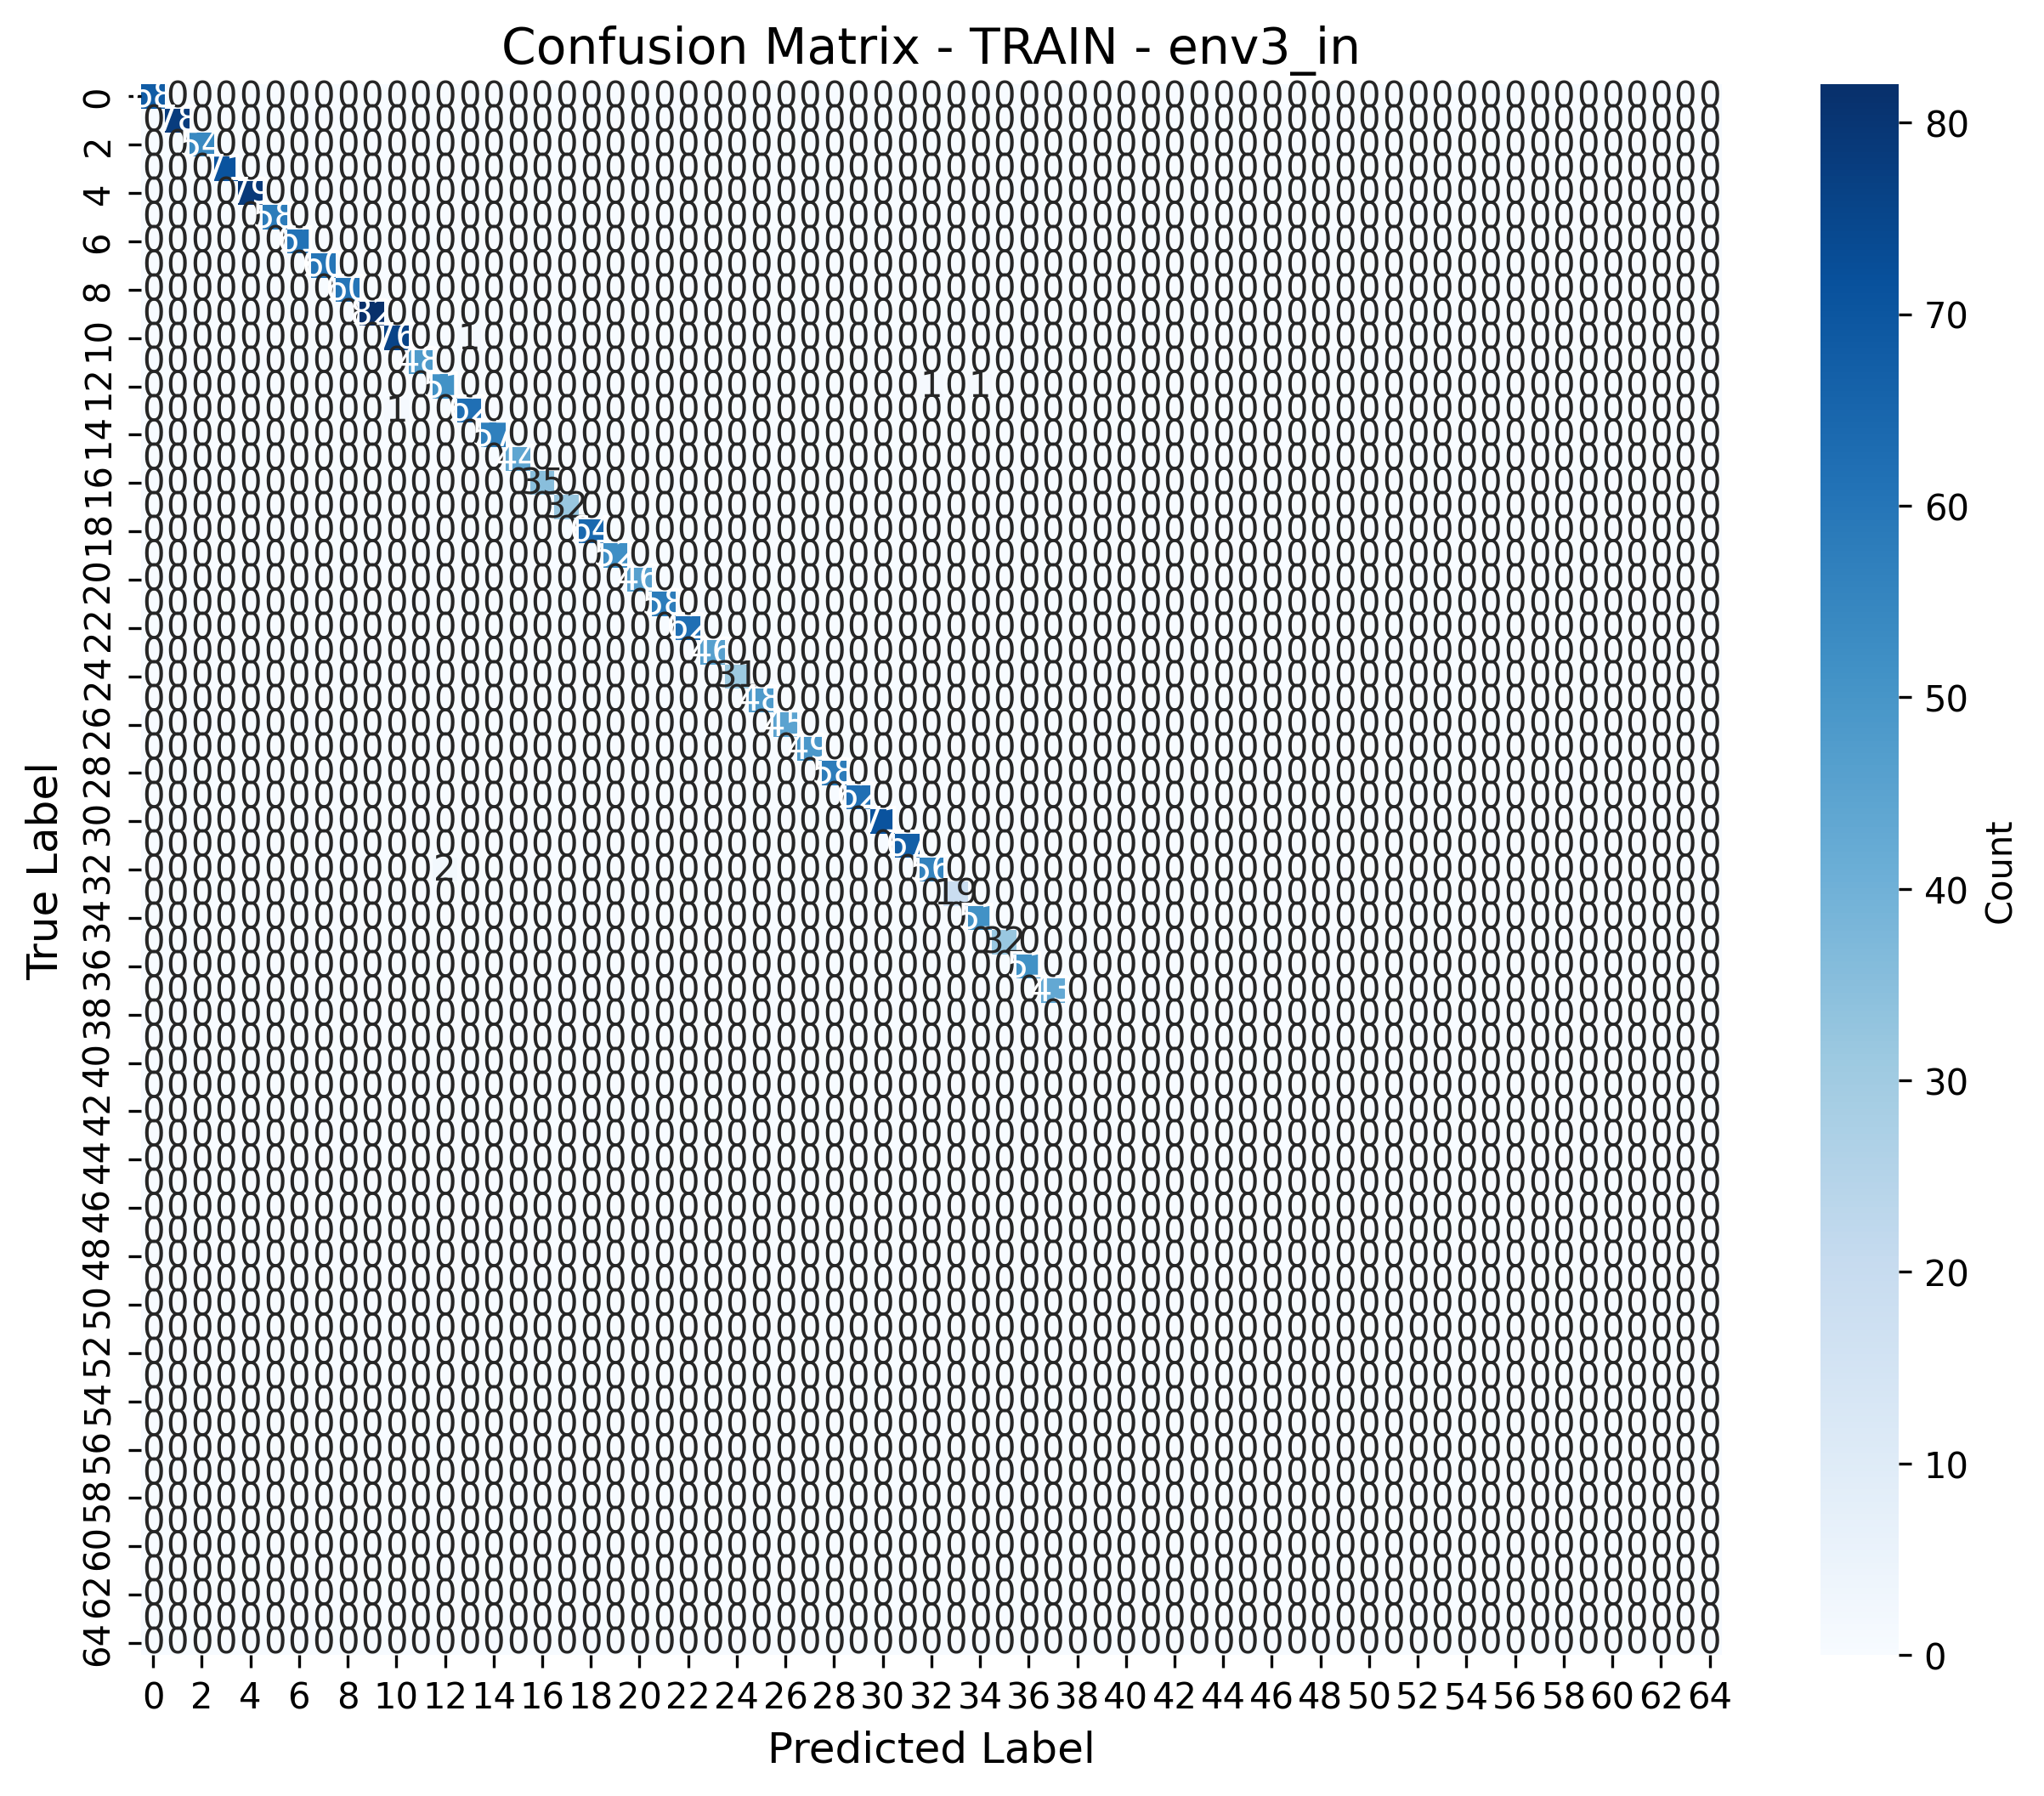


confusion_matrix_VAL_env1_out.png


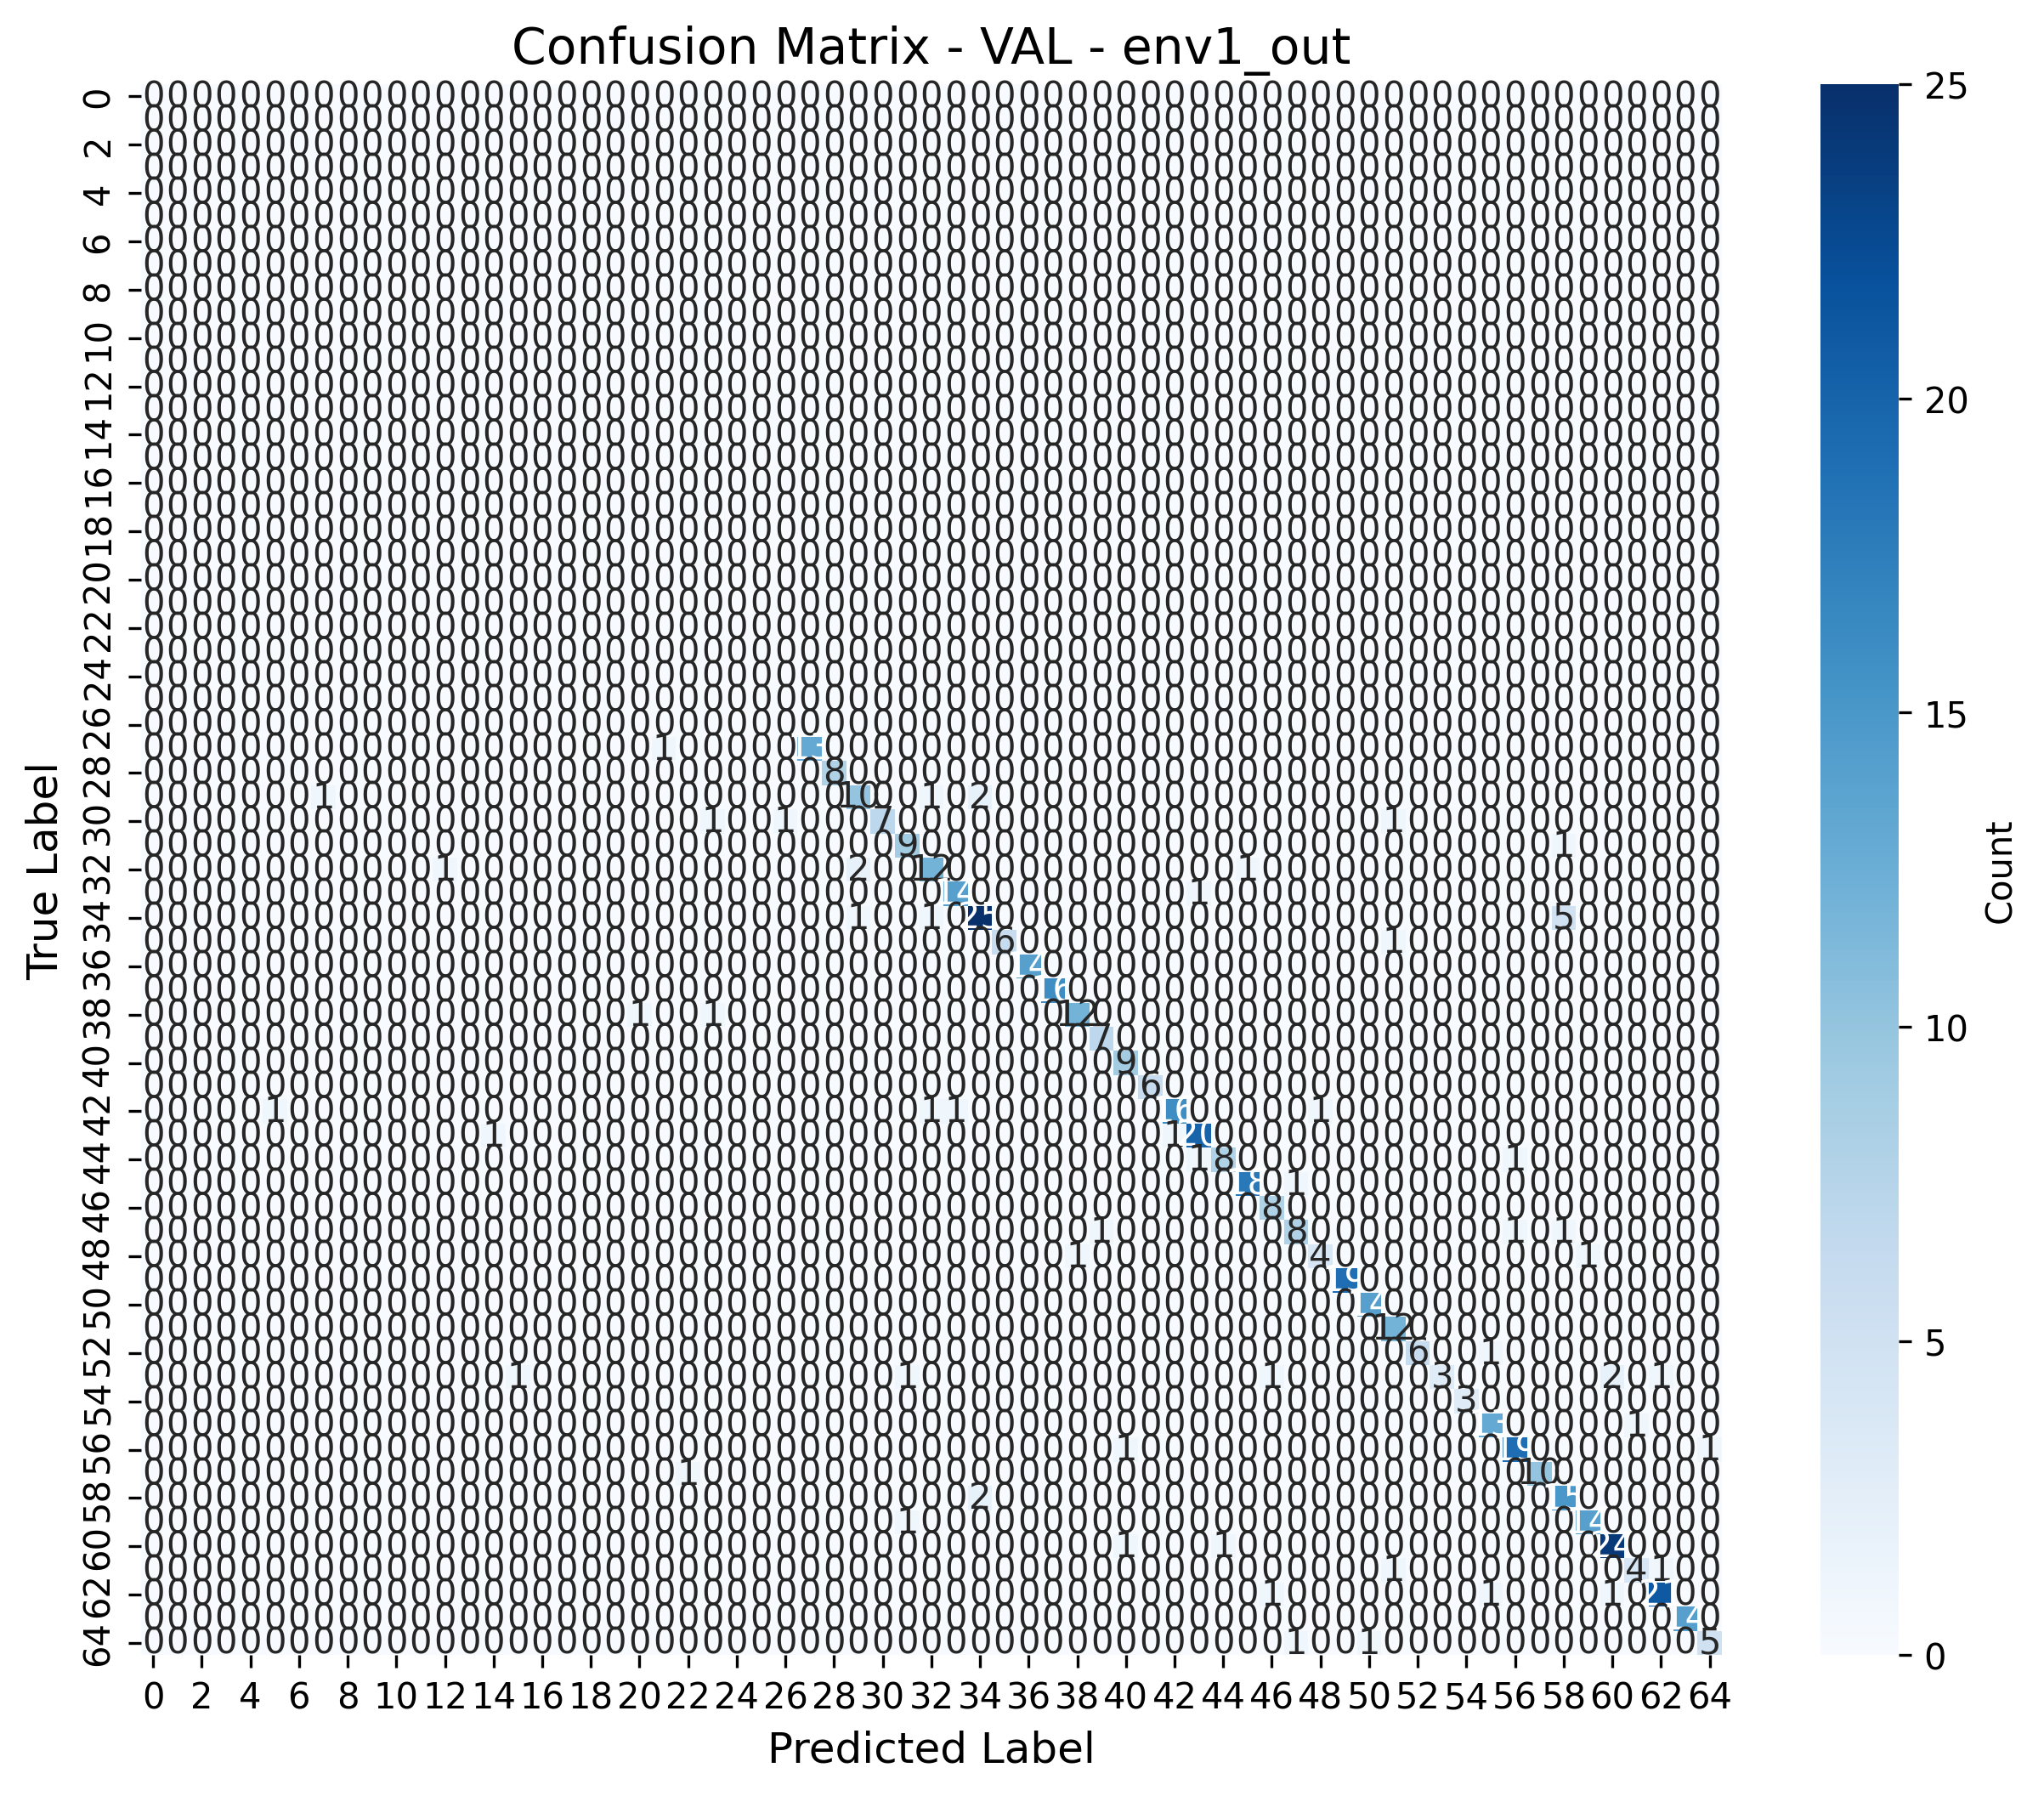


confusion_matrix_VAL_env2_out.png


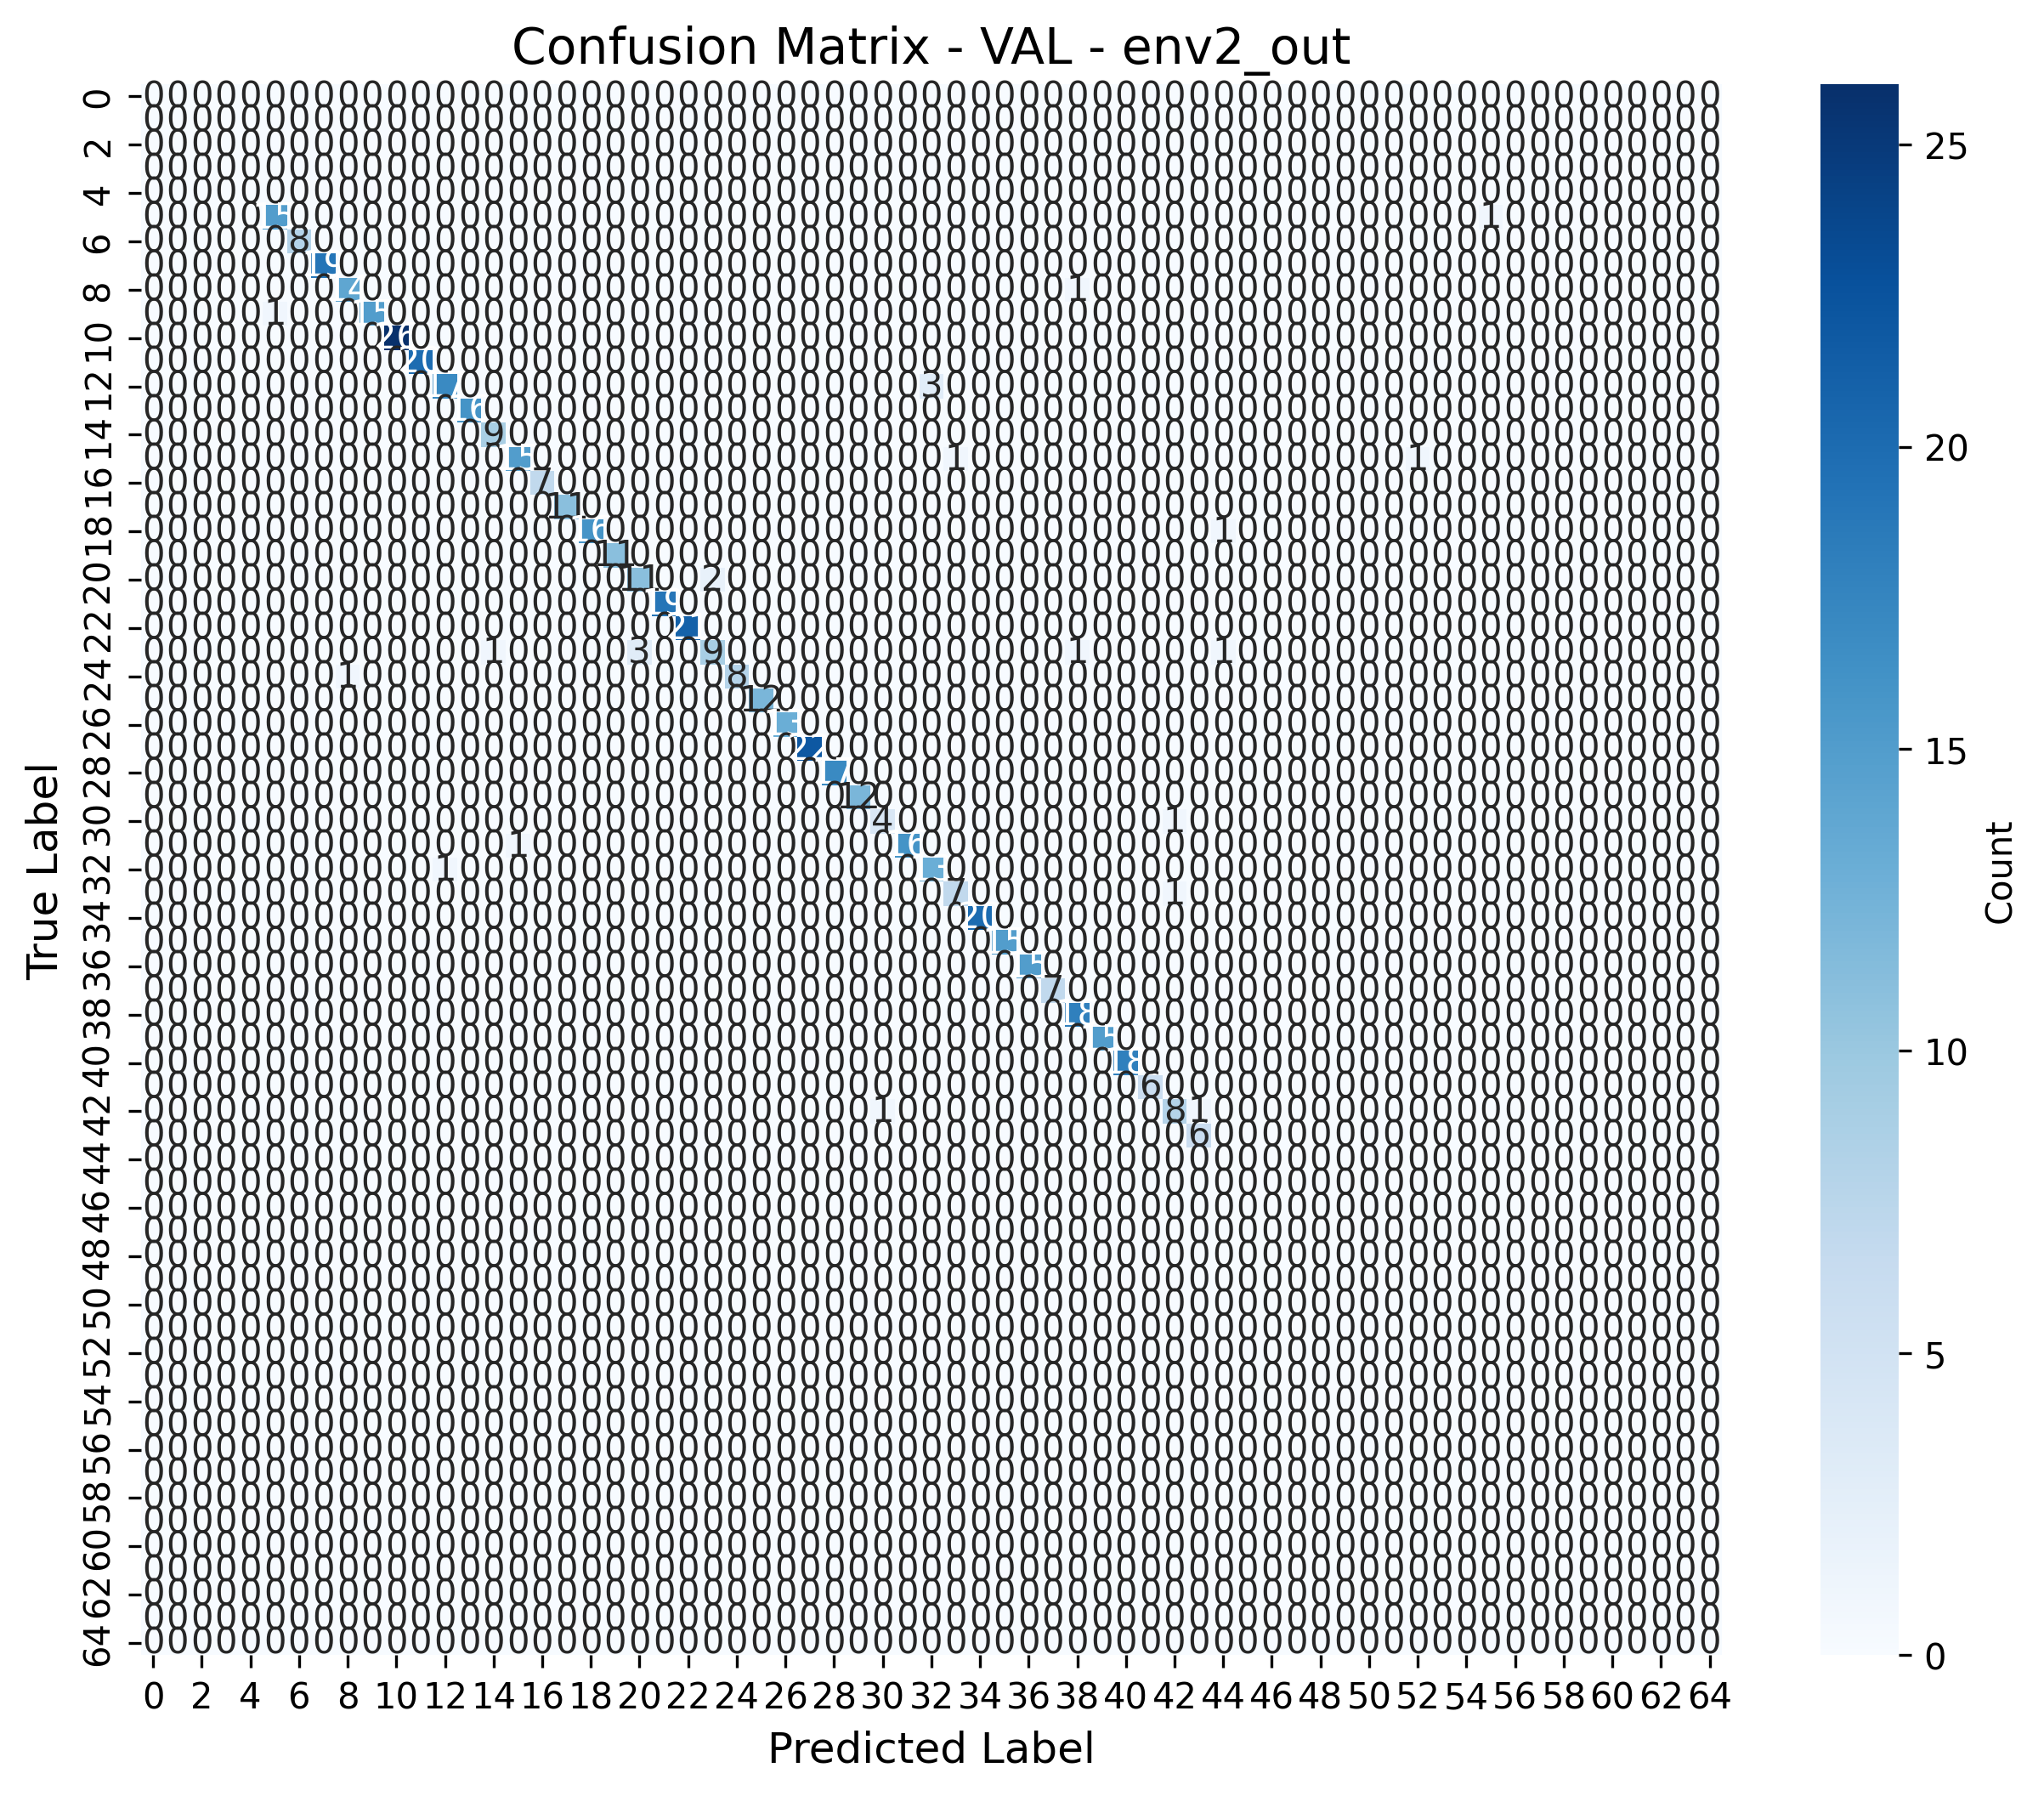


confusion_matrix_VAL_env3_out.png


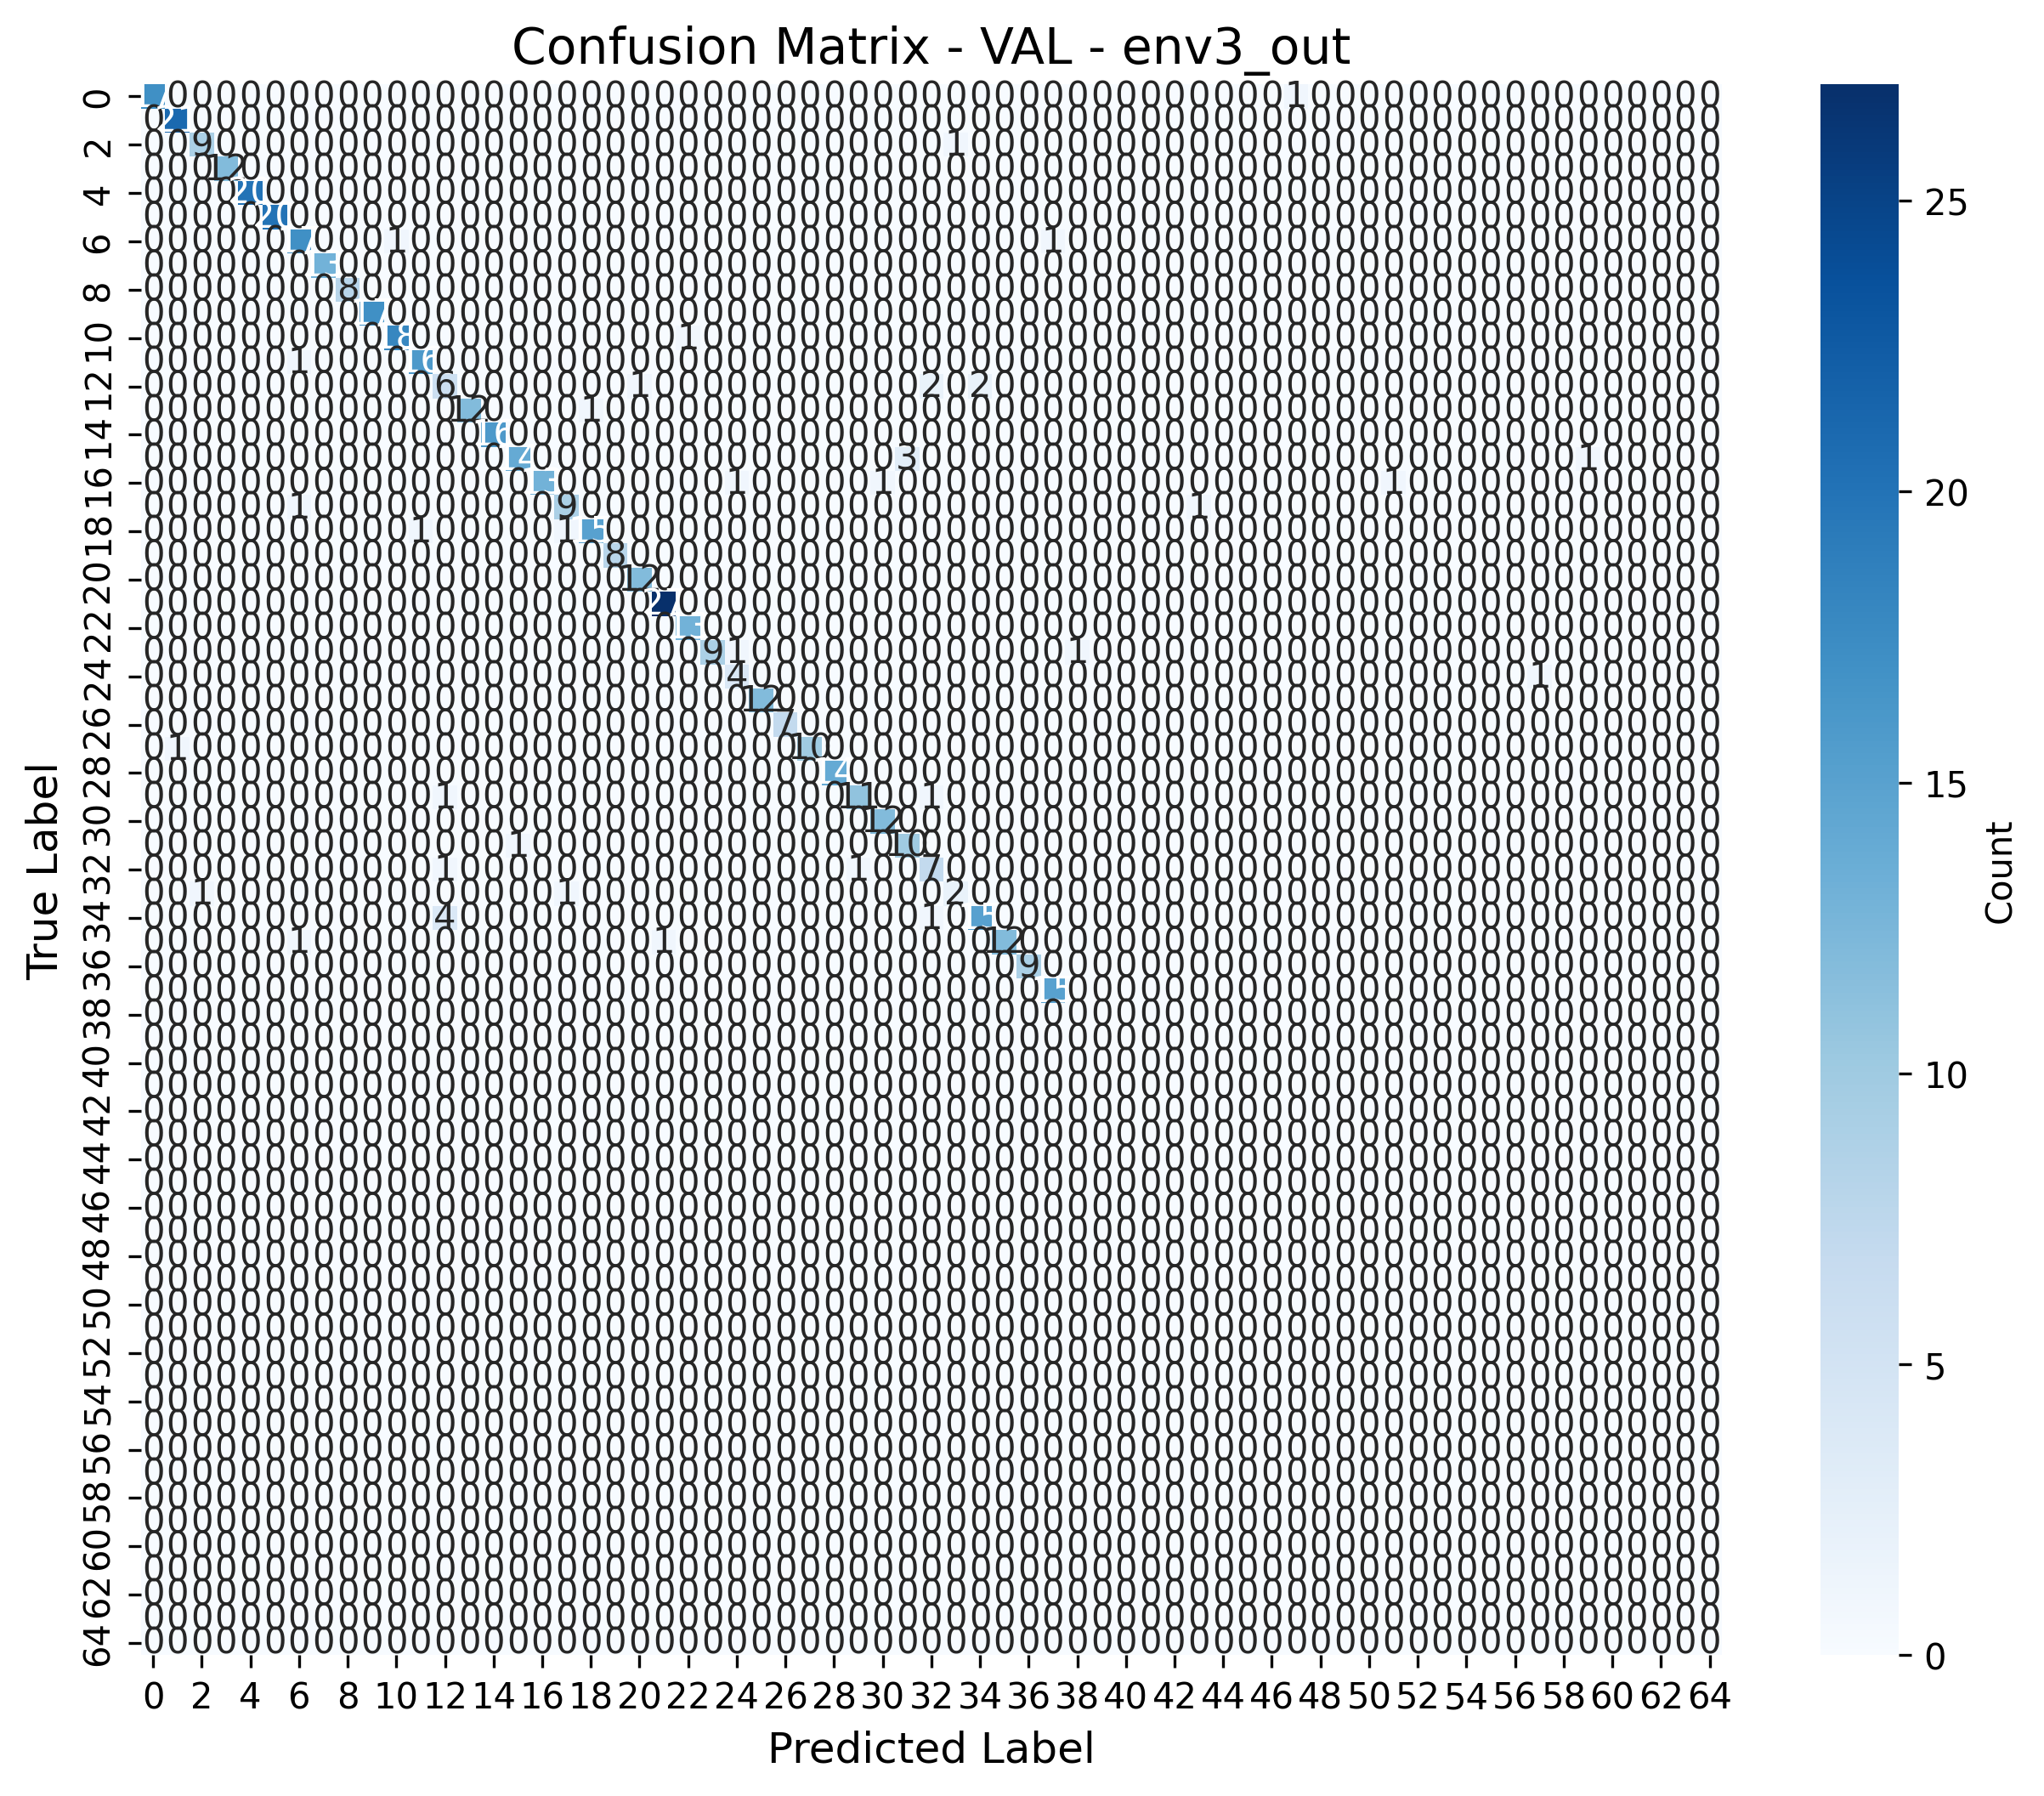



EPOCH TIMES:


In [22]:
output_dir = "/kaggle/working/experiments"
if not os.path.exists(output_dir):
    os.mkdir(output_dir)
exp_name_oh = input()
config["name"] = exp_name_oh

exp_name_oh = config["name"] or f"{config['algo']}_{config['dataset']}_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
exp_dir = Path(output_dir) / exp_name_oh
exp_dir.mkdir(parents=True, exist_ok=True)
log_dir = exp_dir / 'logs'
log_dir.mkdir(parents=True, exist_ok=True)
# Setup logging

config_logging()
logging.info(f"Starting experiment: {exp_name_oh}")
logging.info(f"Output directory: {exp_dir}")

# Save config to experiment directory
with open(exp_dir / "config.json", "w") as f:
    json.dump(config, f, indent=2)


logger = CSVLogger(log_dir / 'metrics.csv',  root_dir=log_dir)## VLCS
dataset_name_oh = config["dataset"][0]
print(dataset_name_oh)



config["backbone"] = "convnext_tiny"
# config["swin_variant"] = "swin_t"  # or "swin_s", "swin_b"
# config["swin_dropout"] = 0.1
config["use_autoaugment"] = False

# Best hyperparameters from Optuna (only for FOND on PACS)
best_hparams = {
    "rtemperature": 0.05806267550007497,
"xdom_lmbd": 4.6620905200273155,
"error_lmbd": 0.1368916207983103,
"xda_alpha": 3.4888418339169354,
"xda_beta": 7.189719965066721,
"lr": 3.0156610365320048e-05,
"weight_decay": 2.1284711395696195e-06,
"batch_size": 32,
     "backbone": "convnext_tiny",
    "pretrained": True,
    "freeze_backbone": True,   # IMPORTANT
    "feature_dim": 768,
}

# Clone config and add best hparams
config_oh = config.copy()
config_oh.update(best_hparams)  # Merge in the tuned hyperparameters

fit_simple(
    exp_dir=str(exp_dir),
    logger=logger,
    seed=config_oh.get("seed", 0),
    trial_seed=config_oh.get("trial_seed", 0),
    hparams_seed=config_oh.get("hparams_seed", 0),
    algorithm_name="FOND",
    dataset_name=dataset_name_oh,
    data_dir=config_oh["data_dir"][dataset_name_oh],
    num_workers=12,
    test_envs=[config_oh["test_set_id"]],
    overlap_type=config_oh.get("overlap", "none"),
    holdout_fraction=config_oh.get("holdout_fraction", 0.2),
    n_steps=config_oh.get("n_epochs"),
    checkpoint_freq=500,
    model_checkpoint=config_oh.get("model_checkpoint", {
        "metric": "val/acc",
        "maximize": True
    }),
    num_domain_linked_classes=config_oh.get("num_domain_linked_classes"),
    num_classes=config_oh.get("num_classes"),
    auto_augment=False,
    augment_search_epochs=config_oh.get("augment_search_epochs", 10),
    config=best_hparams  # ← Pass the tuned hyperparameters here
)

logging.info(f"Experiment complete. Results saved to {exp_dir}")
print(f"\n✓ Experiment complete!")
print(f"  Results: {exp_dir / 'metrics_oh.csv'}")
print(f"  Best model: {exp_dir / 'best_model_oh.ckpt'}")
print(f"  Config: {exp_dir / 'config_oh.json'}")





import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from IPython.display import display, Image
import os

log_dir = f"/kaggle/working/experiments/{exp_name_oh}/logs"

# Get all confusion matrix plot files
cm_files = [f for f in os.listdir(log_dir) if f.startswith('confusion_matrix_') and f.endswith('.png')]

# Display all confusion matrices
print("CONFUSION MATRICES:")
print("="*60)
for cm_file in sorted(cm_files):
    print(f"\n{cm_file}")
    display(Image(filename=os.path.join(log_dir, cm_file)))

# # Display training curves
# print("\n\nTRAINING CURVES:")
# print("="*60)
# display(Image(filename=os.path.join(log_dir, 'training_curves_PACS.png')))

# # Display epoch times
print("\n\nEPOCH TIMES:")
# print("="*60)
# display(Image(filename=os.path.join(log_dir, 'epoch_times_PACS.png')))
